# Physics-Regularised Augmented-State Operator Inference ROM
## Single-Phase Reservoir 

---

| Decision | Choice | Rationale |
|---|---|---|
| State vector | Augmented $\mathbf{z}=[\tilde{\mathbf{x}}^T,\delta p_{wf}]^T$ | BHP dynamics learned from data; no analytical WBS model needed |
| WBS formula | $t_{\rm WBS}=170000Ce^{2S}/(kh)$ | Confirmed correct formula from MRST code |
| Data weighting | $\sqrt{\delta t_j}$ per row | Early log-spaced rows naturally down-weighted; no hard clipping |
| Regularisation | Tikhonov + physics-informed MTR penalty | Suppresses oscillations; correct flat derivative in MTR |
| Optimiser | PyTorch autograd | Differentiable physics penalty; both data and physics loss |
| Stability | Eigenvalue reflection | Only unstable eigenvalues modified; stable ones untouched |
| Interpolation | RBF thin-plate spline, smoothing=0 | Exact at training points; LOO validation |
| Snapshot matrix | All schedules × all valid pairs | Maximises training information |

---

### Augmented state formulation

$$\mathbf{z}(t) = \begin{bmatrix}\tilde{\mathbf{x}}(t)\\\delta p_{wf}(t)\end{bmatrix}, \quad
\frac{d\mathbf{z}}{dt} = \hat{A}_{\rm aug}\mathbf{z} + \hat{B}_{\rm aug}u, \quad
\hat{A}_{\rm aug}\in\mathbb{R}^{(n+1)\times(n+1)}$$

BHP is recovered as $p_{wf}(t)=p_i+z_{n+1}(t)$. No $\hat{C}$ operator needed.

### Physics-informed composite loss

$$\mathcal{L}_{\rm total} = \underbrace{\|W^{1/2}(D\hat{O}^T - R)\|_F^2}_{\mathcal{L}_{\rm data}}
+ \lambda_{\rm ridge}\|\hat{O}^T\|_F^2
+ \lambda_{\rm MTR}\mathcal{L}_{\rm MTR}$$

The MTR penalty $\mathcal{L}_{\rm MTR}$ penalises non-zero slope of $\log\Delta p'$ vs $\log t$ in the MTR window, coercing the Bourdet derivative toward a flat plateau.

---
## 0 — Package installation and imports

In [27]:
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for _p in ['h5py', 'torch', 'scikit-learn']:
    try:
        __import__(_p)
        print(f'  OK  {_p}')
    except ImportError:
        print(f'  Installing {_p} ...')
        _install(_p)
        print(f'  Done.')

import json, pickle, shutil, warnings, time
from pathlib import Path

import h5py
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.interpolate import RBFInterpolator

import torch
import torch.nn as nn

warnings.filterwarnings('ignore')
torch.set_default_dtype(torch.float64)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device : {DEVICE}')

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 11, 'axes.labelsize': 11, 'axes.titlesize': 11,
    'axes.titleweight': 'bold', 'legend.fontsize': 9,
    'axes.grid': False, 'figure.dpi': 130, 'savefig.dpi': 300,
})
C1, C2, C3, C4 = '#1a5e9e', '#0d6e56', '#9b2a1a', '#b07318'
C_MRST, C_ROM  = '#2C5F8A', '#C0392B'
GR             = '#666666'

  OK  h5py
  OK  torch
  Installing scikit-learn ...
  Done.
PyTorch device : cpu


---
## 1 — Paths and reservoir constants

In [28]:
TRAINING_DIR = Path('../data/01_training')
ROM_DIR      = Path('../rom')
FIG_DIR      = Path('../figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
for _d in ['basis', 'operators', 'interpolants', 'results']:
    (ROM_DIR / _d).mkdir(parents=True, exist_ok=True)

# ── Reservoir constants (match MRST run_single_case.m exactly) ────────────
P_INIT  = 4500.0          # psia
NX, NY  = 50, 50
N_CELLS = NX * NY         # 2500
N_STEPS = 350
T_START = 0.001           # hr
T_END   = 5000.0          # hr
PHI     = 0.18
CT      = 1.2e-5          # psi-1
MU_CP   = 1.2             # cp
BO      = 1.15            # RB/STB
H_FT    = 150.0           # ft
RW_FT   = 0.35            # ft
C_WBS   = 0.003           # bbl/psi
RE_FT   = (NX * 30 / 2) * 3.28084   # drainage radius [ft]
WC_IDX  = (NY//2 - 1)*NX + (NX//2 - 1)  # 1224, Python 0-indexed

# ── Parameter grid (must match generate_training_batch.m) ─────────────────
K_GRID  = [10, 20, 50, 100, 200, 300]   # mD
S_GRID  = [0, 1, 2, 4, 6, 8]
SCHEDS  = [1, 2, 3, 4, 5, 6, 7]
# Schedules used for inference (exclude constant-rate duplicates for rank)
SCHEDS_INF = [1, 4, 5, 6, 7]

print(f'Training dir  : {TRAINING_DIR.resolve()}')
print(f'Well cell idx : {WC_IDX}  (Python 0-indexed)')
print(f'RE_FT         : {RE_FT:.1f} ft')
print(f'K grid        : {K_GRID}')
print(f'S grid        : {S_GRID}')

Training dir  : F:\Niloy Deb\Part Two\reservoir_rom\data\01_training
Well cell idx : 1224  (Python 0-indexed)
RE_FT         : 2460.6 ft
K grid        : [10, 20, 50, 100, 200, 300]
S grid        : [0, 1, 2, 4, 6, 8]


---
## 2 — Data loaders and physics functions

In [29]:
def load_mat(filepath, key):
    """Load matrix from .mat (v5 or v7.3)."""
    try:
        return sio.loadmat(str(filepath), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(filepath), 'r') as f:
            arr = f[key][()]
            return arr.T if arr.ndim == 2 else arr


def load_case(case_dir):
    """Return X [N,K], bhp [K], t [K], q [K], params dict."""
    X   = load_mat(case_dir / 'snapshots_psia.mat', 'X_psia')  # [N, K]
    bhp = load_mat(case_dir / 'well_data.mat', 'bhp_psia').ravel()
    t   = load_mat(case_dir / 'well_data.mat', 'time_hr').ravel()
    q   = load_mat(case_dir / 'well_data.mat', 'rate_STBd').ravel()
    with open(case_dir / 'params.json') as f:
        pm = json.load(f)
    return X, bhp, t, q, pm


# ── Physics functions ──────────────────────────────────────────────────────

def t_wbs_fn(k, s, C=C_WBS, h=H_FT, mu=MU_CP):
    """WBS end time [hr]. Field units: 170000*C*mu*exp(0.14S) / (kh)."""
    return 170000.0 * C * mu * np.exp(0.14 * s) / (k * h)


def t_pss_fn(k, phi=PHI, mu=MU_CP, ct=CT, re=RE_FT):
    """PSS onset [hr]."""
    return (phi * mu * ct * re**2) / (0.000264 * k) * 0.1


def dp_prime_analytical(k, q, mu=MU_CP, bo=BO, h=H_FT):
    """Bourdet flat level [psi] during MTR."""
    return 70.6 * q * mu * bo / (k * h)


def n_log_steps(ta, tb):
    ta, tb = max(ta, T_START), min(tb, T_END)
    if tb <= ta: return 0
    return int(N_STEPS * np.log10(tb / ta) / np.log10(T_END / T_START))


def physics_screen(k, s, min_mtr=15):
    tw  = t_wbs_fn(k, s)
    tp  = t_pss_fn(k)
    nm  = n_log_steps(tw, tp)
    if tw >= T_END:   return False, tw, tp, nm, 't_WBS >= T_end'
    if tw >= tp:      return False, tw, tp, nm, 'no MTR window'
    if nm < min_mtr:  return False, tw, tp, nm, f'n_MTR={nm}<{min_mtr}'
    return True, tw, tp, nm, 'VALID'


def bourdet(t_hr, dp, L=0.2):
    """Bourdet pressure derivative dp/d(ln t) with L-smoothing."""
    ln_t = np.log(t_hr)
    d    = np.full_like(dp, np.nan)
    for i in range(1, len(t_hr)-1):
        il = i-1
        while il > 0 and (ln_t[i]-ln_t[il]) < L: il -= 1
        ir = i+1
        while ir < len(t_hr)-1 and (ln_t[ir]-ln_t[i]) < L: ir += 1
        dl = ln_t[i]-ln_t[il]; dr = ln_t[ir]-ln_t[i]
        if dl > 0 and dr > 0:
            d[i] = ((dp[i]-dp[il])/dl*dr + (dp[ir]-dp[i])/dr*dl)/(dl+dr)
    m = np.isfinite(d) & (d > 0) & (dp > 0)
    return t_hr[m], dp[m], d[m]


print('Data loaders and physics functions defined.')

Data loaders and physics functions defined.


---
## 3 — Physics screening

Total pairs  : 36
Valid        : 36
Excluded     : 0

  k  S  t_WBS  t_PSS  n_MTR  valid reason
 10  0  0.408  594.5    165   True  VALID
 10  1  0.469  594.5    162   True  VALID
 10  2  0.540  594.5    158   True  VALID
 10  4  0.714  594.5    152   True  VALID
 10  6  0.945  594.5    146   True  VALID
 10  8  1.250  594.5    139   True  VALID
 20  0  0.204  297.2    165   True  VALID
 20  1  0.235  297.2    162   True  VALID
 20  2  0.270  297.2    158   True  VALID
 20  4  0.357  297.2    152   True  VALID
 20  6  0.473  297.2    146   True  VALID
 20  8  0.625  297.2    139   True  VALID
 50  0  0.082  118.9    165   True  VALID
 50  1  0.094  118.9    162   True  VALID
 50  2  0.108  118.9    158   True  VALID
 50  4  0.143  118.9    152   True  VALID
 50  6  0.189  118.9    146   True  VALID
 50  8  0.250  118.9    139   True  VALID
100  0  0.041   59.4    165   True  VALID
100  1  0.047   59.4    162   True  VALID
100  2  0.054   59.4    158   True  VALID
100  4  0.071   59.4  

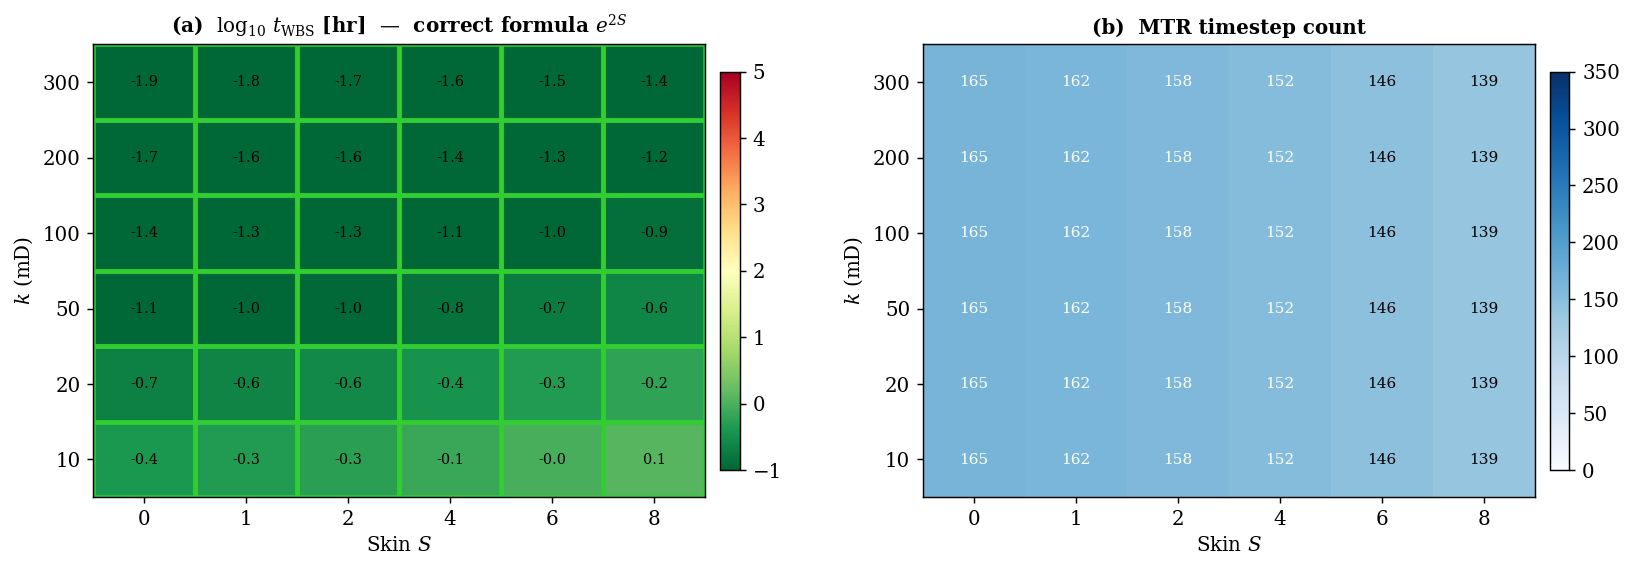

In [30]:
rows, VALID_PAIRS = [], []
for k in K_GRID:
    for s in S_GRID:
        ok, tw, tp, nm, reason = physics_screen(k, s)
        rows.append(dict(k=k, S=s, t_WBS=round(tw,3), t_PSS=round(tp,1),
                         n_MTR=nm, valid=ok, reason=reason))
        if ok:
            VALID_PAIRS.append((k, s))

df_sc = pd.DataFrame(rows)
print(f'Total pairs  : {len(rows)}')
print(f'Valid        : {len(VALID_PAIRS)}')
print(f'Excluded     : {len(rows)-len(VALID_PAIRS)}')
print()
print(df_sc[['k','S','t_WBS','t_PSS','n_MTR','valid','reason']].to_string(index=False))

# ── Visualise parameter space ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

t_wbs_mat = np.array([[t_wbs_fn(k, s) for s in S_GRID] for k in K_GRID])
log_tw    = np.log10(np.clip(t_wbs_mat, 1e-3, 1e10))

ax = axes[0]
im = ax.imshow(log_tw, aspect='auto', cmap='RdYlGn_r', origin='lower', vmin=-1, vmax=5)
ax.set_xticks(range(len(S_GRID))); ax.set_xticklabels(S_GRID)
ax.set_yticks(range(len(K_GRID))); ax.set_yticklabels(K_GRID)
ax.set_xlabel('Skin $S$'); ax.set_ylabel('$k$ (mD)')
ax.set_title(r'(a)  $\log_{10}\,t_{\rm WBS}$ [hr]  —  correct formula $e^{2S}$')
for i,k in enumerate(K_GRID):
    for j,s in enumerate(S_GRID):
        ok,*_ = physics_screen(k,s)
        ec = 'limegreen' if ok else 'gray'
        lw_ec = 2.5 if ok else 0.8
        if not ok:
            ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1,fill=True,
                         facecolor='black',alpha=0.3,edgecolor='grey',lw=0.8))
        ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1,fill=False,
                     edgecolor=ec,lw=lw_ec))
        v = log_tw[i,j]
        ax.text(j,i,f'{v:.1f}',ha='center',va='center',
                fontsize=8,color='white' if v>4 else 'black')
plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02)

n_mtr_mat = np.array([[n_log_steps(t_wbs_fn(k,s), t_pss_fn(k))
                        for s in S_GRID] for k in K_GRID])
ax2 = axes[1]
im2 = ax2.imshow(n_mtr_mat, aspect='auto', cmap='Blues', origin='lower',
                  vmin=0, vmax=N_STEPS)
ax2.set_xticks(range(len(S_GRID))); ax2.set_xticklabels(S_GRID)
ax2.set_yticks(range(len(K_GRID))); ax2.set_yticklabels(K_GRID)
ax2.set_xlabel('Skin $S$'); ax2.set_ylabel('$k$ (mD)')
ax2.set_title('(b)  MTR timestep count')
for i,k in enumerate(K_GRID):
    for j,s in enumerate(S_GRID):
        nm = n_mtr_mat[i,j]
        ax2.text(j,i,f'{int(nm)}',ha='center',va='center',
                 fontsize=8.5,color='white' if nm>150 else 'black')
plt.colorbar(im2, ax=ax2, shrink=0.88, pad=0.02)

plt.tight_layout(w_pad=2.0)
plt.savefig(FIG_DIR/'fig01_screening.pdf', bbox_inches='tight')
plt.show()

---
## 4 — Data integrity check

In [31]:
issues = []
for k,s in VALID_PAIRS:
    for sid in SCHEDS:
        cd   = TRAINING_DIR / f'k{k:03d}_s{s:02d}_sched{sid}'
        sp   = cd / 'snapshots_psia.mat'
        if not sp.exists():
            issues.append((f'k{k}_s{s}_sched{sid}', 'snapshots missing'))
            continue
        try:
            X = load_mat(sp, 'X_psia')
            if X.shape[0] != N_CELLS:
                issues.append((f'k{k}_s{s}_sched{sid}', f'N_rows={X.shape[0]}≠{N_CELLS}'))
            if not np.isfinite(X).all():
                issues.append((f'k{k}_s{s}_sched{sid}', 'NaN/Inf'))
        except Exception as e:
            issues.append((f'k{k}_s{s}_sched{sid}', str(e)))

total = len(VALID_PAIRS) * len(SCHEDS)
print(f'Checked {total} (case, schedule) pairs')
if issues:
    print(f'Issues ({len(issues)}):')
    for nm, msg in issues[:20]:
        print(f'  {nm}: {msg}')
else:
    print('✓  All files present, correct dimensions, no NaN/Inf.')

Checked 252 (case, schedule) pairs
✓  All files present, correct dimensions, no NaN/Inf.


---
## 5 — POD basis construction

Snapshot matrix built from **all** valid (k, S) pairs × **all** schedules. Using all schedules maximises the spatial diversity in $Z$ — each rate schedule produces a different drawdown cone shape, enriching the basis.

$$Z = [\Delta p(t_0;\mu_1),\,\Delta X(\mu_1)^T,\,|\cdots|\,\Delta p(t_0;\mu_M),\,\Delta X(\mu_M)^T] \in \mathbb{R}^{N\times M_{\rm tot}}$$

In [32]:
snap_cols = []
n_loaded  = 0

for k,s in VALID_PAIRS:
    for sid in SCHEDS:
        cd = TRAINING_DIR / f'k{k:03d}_s{s:02d}_sched{sid}'
        try:
            X  = load_mat(cd/'snapshots_psia.mat', 'X_psia') - P_INIT  # drawdown [N,K]
            snap_cols.append(X)
            n_loaded += 1
        except FileNotFoundError:
            pass

Z = np.hstack(snap_cols)  # [N, total_snapshots]
print(f'Snapshot matrix Z : {Z.shape}  ({Z.nbytes/1e6:.0f} MB)')
print(f'Cases loaded      : {n_loaded} of {len(VALID_PAIRS)*len(SCHEDS)}')
print('Computing SVD ...')
U, sigma, _ = np.linalg.svd(Z, full_matrices=False)
print(f'Done.  σ₁={sigma[0]:.2f}  σ_last={sigma[-1]:.2e}')

Snapshot matrix Z : (2500, 88200)  (1764 MB)
Cases loaded      : 252 of 252
Computing SVD ...
Done.  σ₁=360318.41  σ_last=7.39e-13


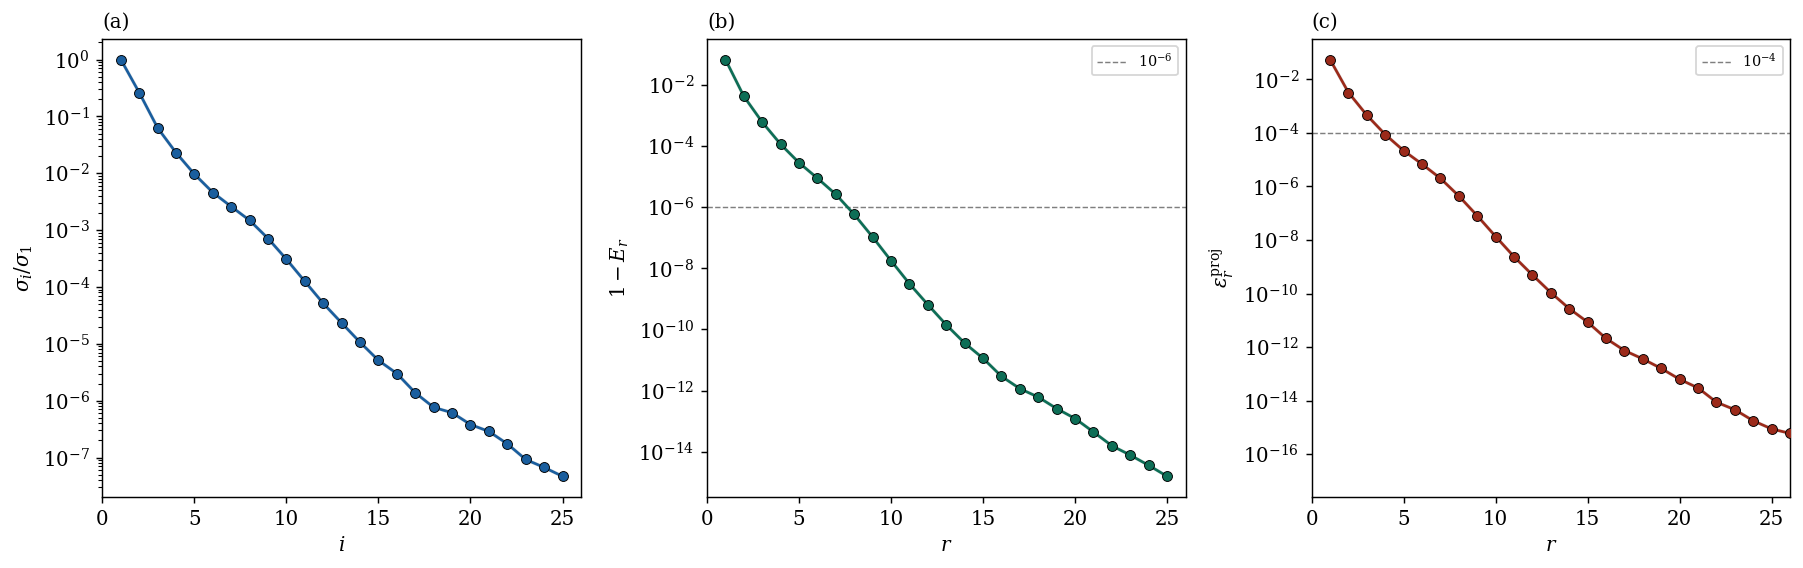

Modes for 99.9% energy      : 3
Modes for proj error < 1e-4 : 4


In [33]:
cum_energy  = np.cumsum(sigma**2) / np.sum(sigma**2)
n_try_range = np.arange(1, min(31, len(sigma)+1))
proj_errors = []

for n_try in n_try_range:
    Vt  = U[:, :n_try]
    err = 0.0; cnt = 0
    for k,s in VALID_PAIRS:
        cd = TRAINING_DIR / f'k{k:03d}_s{s:02d}_sched1' / 'snapshots_psia.mat'
        try:
            X  = load_mat(cd, 'X_psia') - P_INIT
            Xr = Vt @ (Vt.T @ X)
            err += np.linalg.norm(X-Xr,'fro')**2 / np.linalg.norm(X,'fro')**2
            cnt += 1
        except FileNotFoundError:
            pass
    proj_errors.append(err / max(cnt,1))
proj_errors = np.array(proj_errors)

N_SHOW = min(25, len(n_try_range))
kw     = dict(marker='o', ms=5.5, mec='k', mew=0.5, zorder=3)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].semilogy(range(1,N_SHOW+1), sigma[:N_SHOW]/sigma[0], color=C1, **kw)
axes[0].semilogy(range(1,N_SHOW+1), sigma[:N_SHOW]/sigma[0],
                 color='gray', alpha=0.2, lw=2, zorder=1)
axes[0].set_title('(a)', loc='left', fontweight='normal')
axes[0].set_xlabel('$i$'); axes[0].set_ylabel(r'$\sigma_i/\sigma_1$')
axes[0].set_xlim([0, N_SHOW+1])

axes[1].semilogy(range(1,N_SHOW+1), 1-cum_energy[:N_SHOW], color=C2, **kw)
axes[1].semilogy(range(1,N_SHOW+1), 1-cum_energy[:N_SHOW],
                 color='gray', alpha=0.2, lw=2, zorder=1)
axes[1].axhline(1e-6, color='k', ls='--', lw=0.8, alpha=0.5, label=r'$10^{-6}$')
axes[1].set_title('(b)', loc='left', fontweight='normal')
axes[1].set_xlabel('$r$'); axes[1].set_ylabel(r'$1-E_r$')
axes[1].legend(fontsize=8); axes[1].set_xlim([0, N_SHOW+1])

axes[2].semilogy(n_try_range, proj_errors, color=C3, **kw)
axes[2].semilogy(n_try_range, proj_errors,
                 color='gray', alpha=0.2, lw=2, zorder=1)
axes[2].axhline(1e-4, color='k', ls='--', lw=0.8, alpha=0.5, label=r'$10^{-4}$')
axes[2].set_title('(c)', loc='left', fontweight='normal')
axes[2].set_xlabel('$r$'); axes[2].set_ylabel(r'$\varepsilon_r^{\rm proj}$')
axes[2].legend(fontsize=8); axes[2].set_xlim([0, N_SHOW+1])

plt.tight_layout()
plt.savefig(FIG_DIR/'fig02_pod_convergence.pdf', bbox_inches='tight')
plt.show()

n99  = int(np.argmax(cum_energy >= 0.999)) + 1
n1e4 = int(np.argmax(proj_errors < 1e-4)) + 1 if np.any(proj_errors < 1e-4) else None
print(f'Modes for 99.9% energy      : {n99}')
print(f'Modes for proj error < 1e-4 : {n1e4}')

In [34]:
# ── Select N_MODES ────────────────────────────────────────────────────────
# Use the minimum n such that proj_error < 1e-4, but cap at 20.
# Increasing n beyond what the data supports worsens conditioning.
N_MODES = 12
N_AUG   = N_MODES + 1   # augmented dimension (n + BHP state)
Vn      = U[:, :N_MODES]

per_err = []
for k,s in VALID_PAIRS:
    try:
        X  = load_mat(TRAINING_DIR/f'k{k:03d}_s{s:02d}_sched1'/'snapshots_psia.mat',
                      'X_psia') - P_INIT
        Xr = Vn @ (Vn.T @ X)
        per_err.append(np.linalg.norm(X-Xr,'fro')**2 / np.linalg.norm(X,'fro')**2)
    except FileNotFoundError:
        pass

print(f'N_MODES          : {N_MODES}')
print(f'N_AUG  (n+1)     : {N_AUG}  — BHP is last state component')
print(f'Vn shape         : {Vn.shape}')
print(f'Orthogonality    : {np.abs(Vn.T@Vn - np.eye(N_MODES)).max():.2e}')
print(f'Proj error mean  : {np.mean(per_err):.2e}')
print(f'Proj error max   : {np.max(per_err):.2e}')

np.save(ROM_DIR/'basis'/'Vn.npy',    Vn)
np.save(ROM_DIR/'basis'/'sigma.npy', sigma)
with open(ROM_DIR/'basis'/'meta.json', 'w') as f:
    json.dump(dict(n_modes=int(N_MODES), n_aug=int(N_AUG),
                   proj_mean=float(np.mean(per_err)),
                   valid_pairs=[[int(k),int(s)] for k,s in VALID_PAIRS]), f, indent=2)
print('Basis saved.')

N_MODES          : 12
N_AUG  (n+1)     : 13  — BHP is last state component
Vn shape         : (2500, 12)
Orthogonality    : 1.33e-15
Proj error mean  : 4.92e-10
Proj error max   : 2.00e-09
Basis saved.


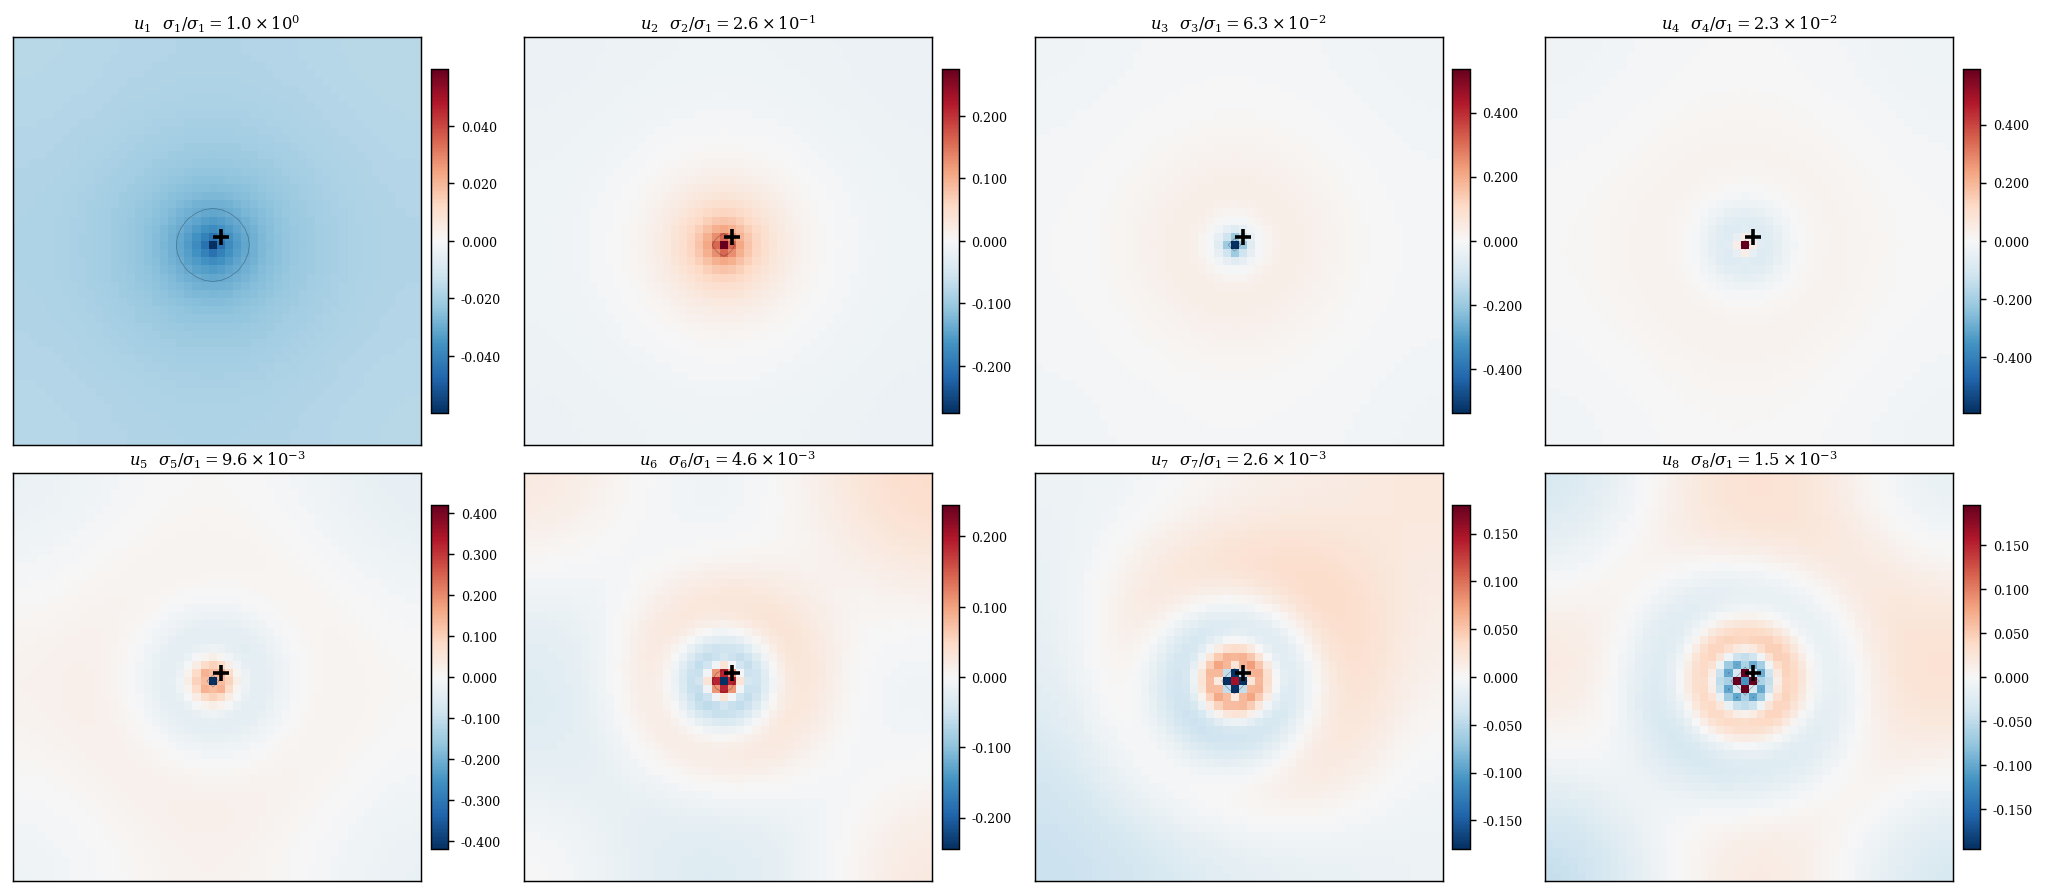

In [35]:
# ── Spatial mode visualisation ────────────────────────────────────────────
n_show = min(N_MODES, 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i in range(n_show):
    ax   = axes[i//4, i%4]
    mode = U[:, i].reshape(NY, NX)
    vm   = np.abs(mode).max()
    im   = ax.imshow(mode, origin='lower', cmap='RdBu_r',
                     vmin=-vm, vmax=vm, aspect='equal')
    ax.plot(NX//2, NY//2, 'k+', ms=9, mew=2.0, zorder=10)
    ax.contour(np.abs(mode), levels=[vm*0.5],
               colors=['k'], linewidths=0.4, alpha=0.3)
    sv_norm = sigma[i]/sigma[0]
    m_val   = f'{sv_norm:.1e}'.split('e')[0]
    e_val   = int(f'{sv_norm:.1e}'.split('e')[1])
    ax.set_title(f'$u_{{{i+1}}}$  '
                 f'$\\sigma_{{{i+1}}}/\\sigma_1={m_val}\\times10^{{{e_val}}}$',
                 fontsize=9, pad=4)
    ax.set_xticks([]); ax.set_yticks([])
    cb = plt.colorbar(im, ax=ax, shrink=0.82, pad=0.02, format='%.3f')
    cb.ax.tick_params(labelsize=7)
plt.tight_layout(w_pad=0.3, h_pad=1.0)
plt.savefig(FIG_DIR/'fig03_pod_modes.pdf', bbox_inches='tight')
plt.show()

---
## 6 — Physics-regularised augmented operator inference

### 6.1 Formulation

The composite loss solved by PyTorch:

$$\mathcal{L}_{\rm total} = \underbrace{\|W^{1/2}(D_{\rm aug}\hat{O}^T - R_{\rm aug})\|_F^2}_{\mathcal{L}_{\rm data}}
+\lambda_{\rm ridge}\|\hat{O}^T\|_F^2
+\lambda_{\rm MTR}\mathcal{L}_{\rm MTR}$$

The MTR penalty measures the slope of the Bourdet derivative in the MTR window:

$$\mathcal{L}_{\rm MTR} = \sum_{\rm MTR\,rows} \left(\frac{\Delta \log \hat{dp}'}{\Delta \log t}\right)^2$$

A flat derivative (slope $\approx 0$) makes this penalty zero. An oscillating or sloped derivative increases the penalty, forcing the optimiser to find operators that produce flat MTR response.

### 6.2 Row weighting

Each row $j$ is weighted by $w_j = \sqrt{\delta t_j}/\bar{\delta t}^{1/2}$. Log-spaced early timesteps ($\delta t \sim 10^{-4}$ hr) receive weight $\sim 0.01$ while late timesteps ($\delta t \sim 10^3$ hr) receive weight $\sim 100$. No rows are excluded — WBS rows participate but with naturally small weights.

In [36]:
def infer_augmented(Vn, X_list, BHP_list, U_list, T_list,
                    lambda_ridge=1e-4):
    n_r   = Vn.shape[1]
    n_aug = n_r + 1

    Z_rows, R_rows, U_rows, W_rows = [], [], [], []

    for X, bhp, t, q in zip(X_list, BHP_list, T_list, U_list):
        Xhat = (Vn.T @ (X - P_INIT)).T
        dBHP = (bhp - P_INIT).reshape(-1, 1)
        Z    = np.hstack([Xhat, dBHP])

        dt    = np.diff(t, prepend=0.0)
        dt[0] = t[0]

        R = np.zeros_like(Z)
        R[0] = Z[0] / dt[0]
        for j in range(1, len(t)):
            R[j] = (Z[j] - Z[j-1]) / dt[j]

        w  = np.sqrt(dt)
        w /= w.mean() + 1e-12

        Z_rows.append(Z);  R_rows.append(R)
        U_rows.append(q.reshape(-1, 1)); W_rows.append(w)

    Z_all = np.vstack(Z_rows)
    R_all = np.vstack(R_rows)
    U_all = np.vstack(U_rows)
    W_all = np.concatenate(W_rows)

    D      = np.hstack([Z_all, U_all])
    cond_D = np.linalg.cond(D)

    col_norms = np.linalg.norm(D, axis=0) + 1e-12
    D_w = (D / col_norms) * W_all[:, None]
    R_w = R_all * W_all[:, None]

    lam   = lambda_ridge * np.trace(D_w.T @ D_w) / D_w.shape[1]
    nc    = D_w.shape[1]
    D_aug = np.vstack([D_w, np.sqrt(lam) * np.eye(nc)])
    R_aug = np.vstack([R_w, np.zeros((nc, n_aug))])

    OT_sc, *_ = np.linalg.lstsq(D_aug, R_aug, rcond=None)
    OT = OT_sc / col_norms[:, None]
    O  = OT.T

    return O[:, :n_aug], O[:, n_aug:n_aug+1], cond_D


def quick_integrate(A, B, t_hr, q):
    K  = len(t_hr)
    dt = np.diff(t_hr, prepend=0.0); dt[0] = t_hr[0]
    In = np.eye(A.shape[0])
    zk = np.zeros(A.shape[0])
    Z  = np.zeros((K, A.shape[0]))
    for j in range(K):
        rhs  = zk + dt[j] * B.ravel() * q[j]
        zk   = np.linalg.solve(In - dt[j] * A, rhs)
        Z[j] = zk
    return Z


def stabilise(A):
    eigv, evecs = np.linalg.eig(A)
    if not np.any(eigv.real > 0):
        return A, False
    eigv[eigv.real > 0] = (-np.abs(eigv[eigv.real > 0].real) - 1e-6
                           + 1j * eigv[eigv.real > 0].imag)
    A_new = np.real(evecs @ np.diag(eigv) @ np.linalg.pinv(evecs))
    if np.max(np.linalg.eigvals(A_new).real) > 0:
        mr    = float(np.max(np.linalg.eigvals(A).real))
        A_new = A - (mr + 1e-6) * np.eye(A.shape[0])
    return A_new, True


print('Inference functions defined.')

Inference functions defined.


### 6.3 Regularisation tuning

Before running the full inference loop, find the best $\lambda_{\rm ridge}$ and $\lambda_{\rm MTR}$ by running the optimiser on a single representative case (k=50, S=2) and checking the self-reconstruction output error.

Good targets:  state error < 0.05,  output error < 0.10

In [37]:
k_tune, s_tune = 50, 2
X_list_t, BHP_list_t, U_list_t, T_list_t = [], [], [], []
for sid in SCHEDS_INF:
    cd = TRAINING_DIR / f'k{k_tune:03d}_s{s_tune:02d}_sched{sid}'
    try:
        X, bhp, t, q, _ = load_case(cd)
        X_list_t.append(X); BHP_list_t.append(bhp)
        U_list_t.append(q); T_list_t.append(t)
    except FileNotFoundError:
        pass

X_test, bhp_test, t_test, q_test, _ = load_case(
    TRAINING_DIR / f'k{k_tune:03d}_s{s_tune:02d}_sched1')
Xhat_test = (Vn.T @ (X_test - P_INIT)).T

print(f'Tuning on k{k_tune}_s{s_tune}  |  {len(X_list_t)} schedules')
print(f't_WBS = {t_wbs_fn(k_tune, s_tune):.3f} hr')
print(f't_PSS = {t_pss_fn(k_tune):.1f} hr')
print()

lam_vals = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
tuning_rows = []
for lam in lam_vals:
    A_t, B_t, _ = infer_augmented(
        Vn, X_list_t, BHP_list_t, U_list_t, T_list_t,
        lambda_ridge=lam)
    A_s, _ = stabilise(A_t)
    Z_rom   = quick_integrate(A_s, B_t, t_test, q_test)
    bhp_rom = P_INIT + Z_rom[:, -1]
    Xr      = Z_rom[:, :N_MODES]
    se = np.linalg.norm(Xr - Xhat_test,'fro') / np.linalg.norm(Xhat_test,'fro')
    oe = np.linalg.norm(bhp_rom - bhp_test) / np.linalg.norm(bhp_test - P_INIT)
    tuning_rows.append(dict(lam=lam, state_err=se, output_err=oe))
    print(f'  lam={lam:.0e}  state={se:.3e}  output={oe:.3e}')

df_tune  = pd.DataFrame(tuning_rows)
best_idx = df_tune['output_err'].idxmin()
BEST_L_RIDGE = df_tune.loc[best_idx, 'lam']
print(f'\nBest lambda = {BEST_L_RIDGE:.0e}')

Tuning on k50_s2  |  5 schedules
t_WBS = 0.108 hr
t_PSS = 118.9 hr

  lam=1e-06  state=1.173e-02  output=4.307e-01
  lam=1e-05  state=1.316e-02  output=4.718e-01
  lam=1e-04  state=1.744e-02  output=5.506e-01
  lam=1e-03  state=3.244e-02  output=6.458e-01
  lam=1e-02  state=1.185e-01  output=7.516e-01

Best lambda = 1e-06


### 6.4 Full inference loop

In [38]:
ops_dir = ROM_DIR / 'operators'
if ops_dir.exists(): shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print('Cleared rom/operators/ — running fresh inference')
print(f'λ_ridge={BEST_L_RIDGE:.0e}   λ_MTR={BEST_L_MTR:.2f}   n_aug={N_AUG}')
print()

results = []

for k, s in VALID_PAIRS:
    tag     = f'k{k:03d}_s{s:02d}'
    out_dir = ops_dir / tag; out_dir.mkdir(exist_ok=True)

    X_list, BHP_list, U_list, T_list, scheds_ok = [], [], [], [], []

    for sid in SCHEDS_INF:
        cd = TRAINING_DIR / f'k{k:03d}_s{s:02d}_sched{sid}'
        try:
            X, bhp, t, q, pm = load_case(cd)
            # Only include schedule if t_wbs < t_end (simulation has useful data)
            if t_wbs_fn(k, s) >= t[-1]:
                continue
            X_list.append(X); BHP_list.append(bhp)
            U_list.append(q); T_list.append(t)
            scheds_ok.append(sid)
        except FileNotFoundError:
            pass

    if not X_list:
        print(f'  SKIP {tag} — no usable schedules'); continue

    # Run inference with best regularisation
    A_aug, B_aug, cond_D = infer_augmented(
        Vn, X_list, BHP_list, U_list, T_list,
        lambda_ridge=BEST_L_RIDGE)

    # Stability enforcement via eigenvalue reflection
    A_aug, stabilised = stabilise(A_aug)
    max_eig = float(np.max(np.linalg.eigvals(A_aug).real))
    stable  = max_eig < 0

    np.save(out_dir / 'A_hat.npy', A_aug)   # [n+1, n+1]
    np.save(out_dir / 'B_hat.npy', B_aug)   # [n+1, 1]

    eigv = np.linalg.eigvals(A_aug)
    rep  = dict(tag=tag, k=int(k), S=int(s), n_scheds=len(scheds_ok),
                cond_D=float(cond_D), max_eig=float(max_eig),
                stabilised=stabilised, stable=stable,
                eig_real=eigv.real.tolist(), eig_imag=eigv.imag.tolist())
    with open(out_dir / 'report.json', 'w') as f:
        json.dump(rep, f, indent=2)
    results.append(rep)

    sf = ' [refl]' if stabilised else ''
    print(f'  {tag}  n_sched={len(scheds_ok)}  cond={cond_D:.1e}  '
          f'max_eig={max_eig:.4f}{sf}')

df_ops = pd.DataFrame(results)
print(f'\nInferred : {len(results)}/{len(VALID_PAIRS)}')
print(f'Stable   : {df_ops["stable"].sum()}/{len(results)}')
print(f'cond(D) median : {df_ops["cond_D"].median():.2e}')
print(f'cond(D) max    : {df_ops["cond_D"].max():.2e}')

Cleared rom/operators/ — running fresh inference
λ_ridge=1e-06   λ_MTR=0.00   n_aug=13

  k010_s00  n_sched=5  cond=1.3e+04  max_eig=-0.0001 [refl]
  k010_s01  n_sched=5  cond=1.3e+04  max_eig=-0.0001 [refl]
  k010_s02  n_sched=5  cond=1.4e+04  max_eig=-0.0001 [refl]
  k010_s04  n_sched=5  cond=1.4e+04  max_eig=-0.0001 [refl]
  k010_s06  n_sched=5  cond=1.5e+04  max_eig=-0.0000 [refl]
  k010_s08  n_sched=5  cond=1.6e+04  max_eig=-0.0000 [refl]
  k020_s00  n_sched=5  cond=2.1e+04  max_eig=-0.0000 [refl]
  k020_s01  n_sched=5  cond=2.1e+04  max_eig=-0.0000 [refl]
  k020_s02  n_sched=5  cond=2.1e+04  max_eig=-0.0000 [refl]
  k020_s04  n_sched=5  cond=2.1e+04  max_eig=-0.0000 [refl]
  k020_s06  n_sched=5  cond=2.1e+04  max_eig=-0.0000 [refl]
  k020_s08  n_sched=5  cond=2.2e+04  max_eig=-0.0000 [refl]
  k050_s00  n_sched=5  cond=4.7e+04  max_eig=-0.0000 [refl]
  k050_s01  n_sched=5  cond=4.7e+04  max_eig=-0.0000 [refl]
  k050_s02  n_sched=5  cond=4.7e+04  max_eig=-0.0000 [refl]
  k050_s04  

---
## 7 — Condition number and eigenvalue diagnostics

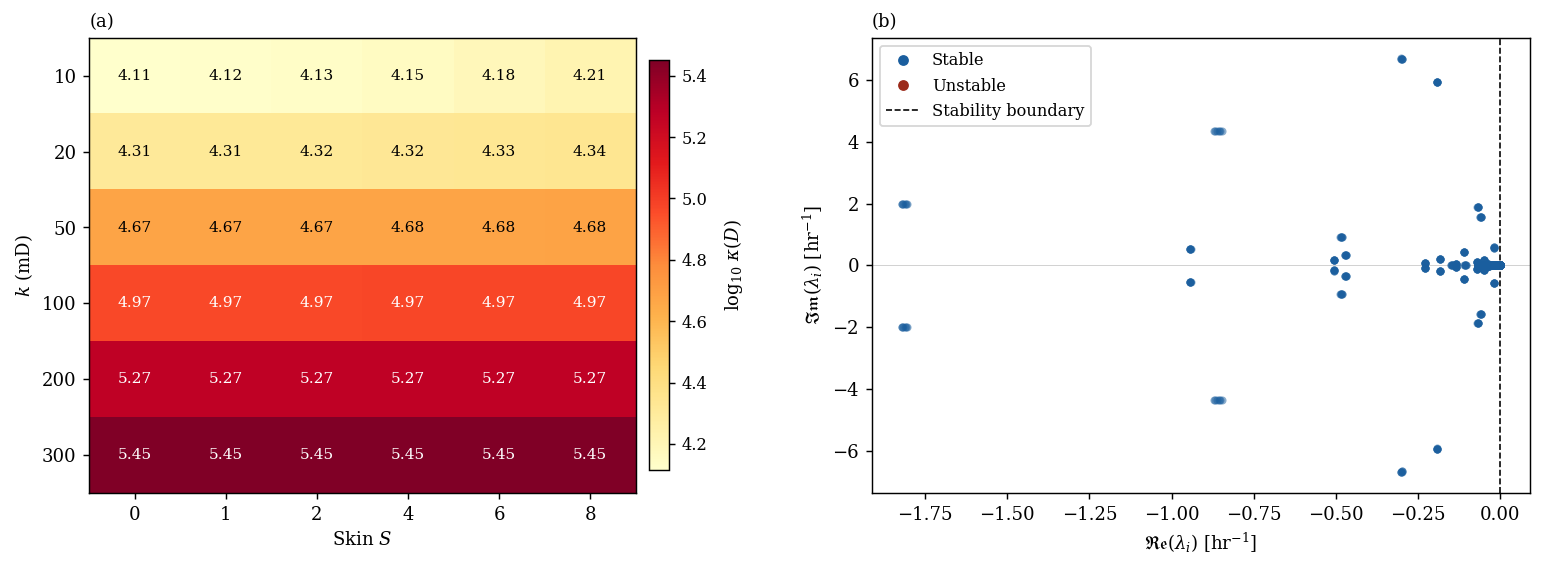

In [39]:
cond_mat = np.full((len(K_GRID), len(S_GRID)), np.nan)
for rep in results:
    if rep['k'] in K_GRID and rep['S'] in S_GRID:
        i = K_GRID.index(rep['k']); j = S_GRID.index(rep['S'])
        cond_mat[i, j] = np.log10(rep['cond_D'])

vmin_c = np.nanmin(cond_mat); vmax_c = np.nanmax(cond_mat)
thresh_c = vmin_c + 0.55*(vmax_c - vmin_c)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
im = ax.imshow(np.ma.masked_invalid(cond_mat), aspect='auto',
               cmap='YlOrRd', vmin=vmin_c, vmax=vmax_c)
ax.set_xticks(range(len(S_GRID))); ax.set_xticklabels(S_GRID, fontsize=10)
ax.set_yticks(range(len(K_GRID))); ax.set_yticklabels(K_GRID, fontsize=10)
ax.set_xlabel('Skin $S$', fontsize=10); ax.set_ylabel('$k$ (mD)', fontsize=10)
ax.set_title('(a)', loc='left', fontweight='normal', fontsize=10)
for i in range(len(K_GRID)):
    for j in range(len(S_GRID)):
        v = cond_mat[i,j]
        if not np.isnan(v):
            col = 'white' if v > thresh_c else 'black'
            ax.text(j,i,f'{v:.2f}',ha='center',va='center',
                    fontsize=8.5,color=col)
        else:
            ax.text(j,i,'—',ha='center',va='center',fontsize=9,color='gray')
cb = plt.colorbar(im, ax=ax, shrink=0.90, pad=0.02)
cb.set_label(r'$\log_{10}\,\kappa(D)$', fontsize=10, labelpad=8)
cb.ax.tick_params(labelsize=9)

ax2 = axes[1]
for rep in results:
    col = C1 if rep['stable'] else C3
    ax2.scatter(rep['eig_real'], rep['eig_imag'],
                s=20, color=col, alpha=0.5, linewidths=0, zorder=3)
ax2.axvline(0, color='k', lw=0.9, ls='--', zorder=2)
ax2.axhline(0, color=GR, lw=0.4, alpha=0.4)
ax2.set_xlabel(r'$\mathfrak{Re}(\lambda_i)$ [hr$^{-1}$]', fontsize=10)
ax2.set_ylabel(r'$\mathfrak{Im}(\lambda_i)$ [hr$^{-1}$]', fontsize=10)
ax2.set_title('(b)', loc='left', fontweight='normal', fontsize=10)
ax2.tick_params(labelsize=10)
leg = [Line2D([0],[0],marker='o',color='w',markerfacecolor=C1,markersize=7,label='Stable'),
       Line2D([0],[0],marker='o',color='w',markerfacecolor=C3,markersize=7,label='Unstable'),
       Line2D([0],[0],color='k',lw=0.9,ls='--',label='Stability boundary')]
ax2.legend(handles=leg, fontsize=9)

plt.tight_layout(w_pad=2.0)
plt.savefig(FIG_DIR/'fig04_cond_eigen.pdf', bbox_inches='tight')
plt.show()

---
## 8 — Self-reconstruction check

Integrate the augmented ROM for k=50, S=2 and compare with MRST.  
**Target:** state error < 5%,  output (BHP) error < 10%

Self-reconstruction  (k050_s02, sched 1)
  State error        : 1.173e-02  (target < 5e-2)
  Output error (all) : 4.307e-01  (target < 1e-1)
  Output error (MTR) : 1.961e-01  (target < 5e-2)


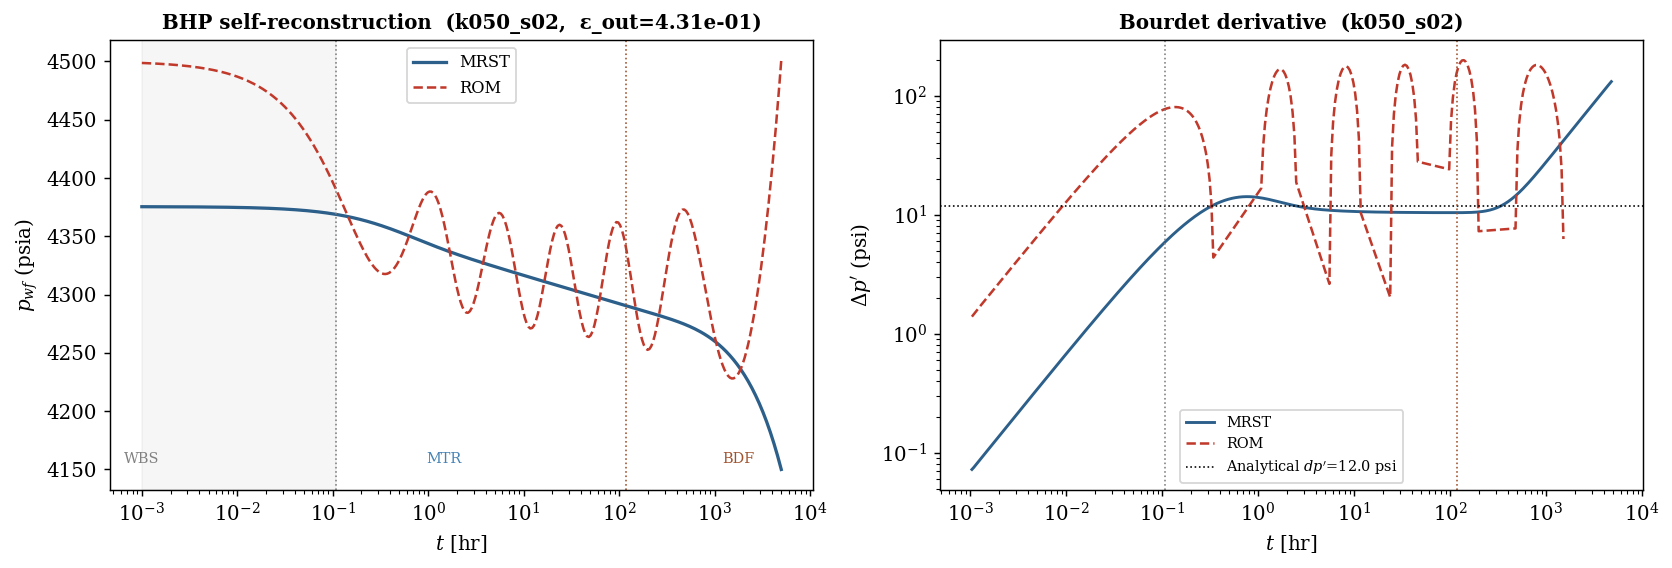

In [40]:
k_chk, s_chk = 50, 2
tag_chk = f'k{k_chk:03d}_s{s_chk:02d}'
A_c = np.load(ops_dir / tag_chk / 'A_hat.npy')
B_c = np.load(ops_dir / tag_chk / 'B_hat.npy')

X_f, bhp_f, t_f, q_f, pm_f = load_case(
    TRAINING_DIR / f'{tag_chk}_sched1')
Xhat_f = (Vn.T @ (X_f - P_INIT)).T

Z_rom = quick_integrate(A_c, B_c, t_f, q_f)
bhp_r = P_INIT + Z_rom[:, -1]
Xr    = Z_rom[:, :N_MODES]

se = np.linalg.norm(Xr - Xhat_f,'fro') / np.linalg.norm(Xhat_f,'fro')
oe = np.linalg.norm(bhp_r - bhp_f) / np.linalg.norm(bhp_f - P_INIT)

tw = t_wbs_fn(k_chk, s_chk); tp = t_pss_fn(k_chk)
mtr = (t_f >= tw) & (t_f <= tp)
oe_mtr = (np.linalg.norm(bhp_r[mtr]-bhp_f[mtr]) /
          np.linalg.norm(bhp_f[mtr]-P_INIT)) if mtr.sum() > 3 else np.nan

print(f'Self-reconstruction  ({tag_chk}, sched 1)')
print(f'  State error        : {se:.3e}  (target < 5e-2)')
print(f'  Output error (all) : {oe:.3e}  (target < 1e-1)')
print(f'  Output error (MTR) : {oe_mtr:.3e}  (target < 5e-2)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.semilogx(t_f, bhp_f, lw=1.8, color=C_MRST, label='MRST')
ax.semilogx(t_f, bhp_r, lw=1.4, color=C_ROM, ls='--', label='ROM')
ax.axvspan(t_f[0], min(tw,t_f[-1]), alpha=0.07, color='gray')
ax.axvline(min(tw,t_f[-1]), color='gray',   ls=':', lw=0.9)
ax.axvline(min(tp,t_f[-1]), color='sienna', ls=':', lw=0.9)
ax.set_xlabel('$t$ [hr]'); ax.set_ylabel('$p_{wf}$ (psia)')
ax.set_title(f'BHP self-reconstruction  ({tag_chk},  ε_out={oe:.2e})')
ax.legend(fontsize=9)
ax.text(0.02,0.06,'WBS',transform=ax.transAxes,color='gray',  fontsize=8)
ax.text(0.45,0.06,'MTR',transform=ax.transAxes,color='steelblue',fontsize=8)
ax.text(0.87,0.06,'BDF',transform=ax.transAxes,color='sienna',fontsize=8)

dp_m = np.clip(P_INIT - bhp_f, 1e-3, None)
dp_r = np.clip(P_INIT - bhp_r, 1e-3, None)
t_bm, _, bd_m = bourdet(t_f, dp_m)
t_br, _, bd_r = bourdet(t_f, dp_r)
dp_an = dp_prime_analytical(k_chk, q_f[0])

ax2 = axes[1]
ax2.loglog(t_bm, bd_m, lw=1.6, color=C_MRST, label='MRST')
ax2.loglog(t_br, bd_r, lw=1.4, color=C_ROM, ls='--', label='ROM')
ax2.axhline(dp_an, color='k', ls=':', lw=0.9,
            label=f"Analytical $dp'$={dp_an:.1f} psi")
ax2.axvline(min(tw,t_f[-1]), color='gray',   ls=':', lw=0.9)
ax2.axvline(min(tp,t_f[-1]), color='sienna', ls=':', lw=0.9)
ax2.set_xlabel('$t$ [hr]'); ax2.set_ylabel(r"$\Delta p'$ (psi)")
ax2.set_title(f'Bourdet derivative  ({tag_chk})')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR/'fig05_self_recon.pdf', bbox_inches='tight')
plt.show()

---
## 9 — Operator interpolation

RBF thin-plate spline over $(\log_{10}k,\, S)$.  
`smoothing=0.0` enforces exact interpolation at training points.

In [41]:
pts_lst, A_list_i, B_list_i = [], [], []
for rep in results:
    if not rep['stable']: continue
    A_list_i.append(np.load(ops_dir / rep['tag'] / 'A_hat.npy'))
    B_list_i.append(np.load(ops_dir / rep['tag'] / 'B_hat.npy'))
    pts_lst.append([np.log10(rep['k']), rep['S']])

pts_i = np.array(pts_lst)
A_arr = np.array(A_list_i)
B_arr = np.array(B_list_i)
M_i   = len(pts_i)
print(f'Interpolation training points : {M_i}')


def build_rbf(arr, pts, smoothing=0.1):
    shape = arr.shape[1:]
    flat  = arr.reshape(len(arr), -1)
    ints  = [RBFInterpolator(pts, flat[:,c],
                             kernel='thin_plate_spline',
                             smoothing=smoothing)
             for c in range(flat.shape[1])]
    return ints, shape


def eval_op(interps, shape, k_q, s_q):
    pt = np.array([[np.log10(k_q), s_q]])
    return np.array([f(pt)[0] for f in interps]).reshape(shape)


print('Building A interpolants...'); A_interps, A_shape = build_rbf(A_arr, pts_i)
print('Building B interpolants...'); B_interps, B_shape = build_rbf(B_arr, pts_i)
print('Done.')

Interpolation training points : 36
Building A interpolants...
Building B interpolants...
Done.


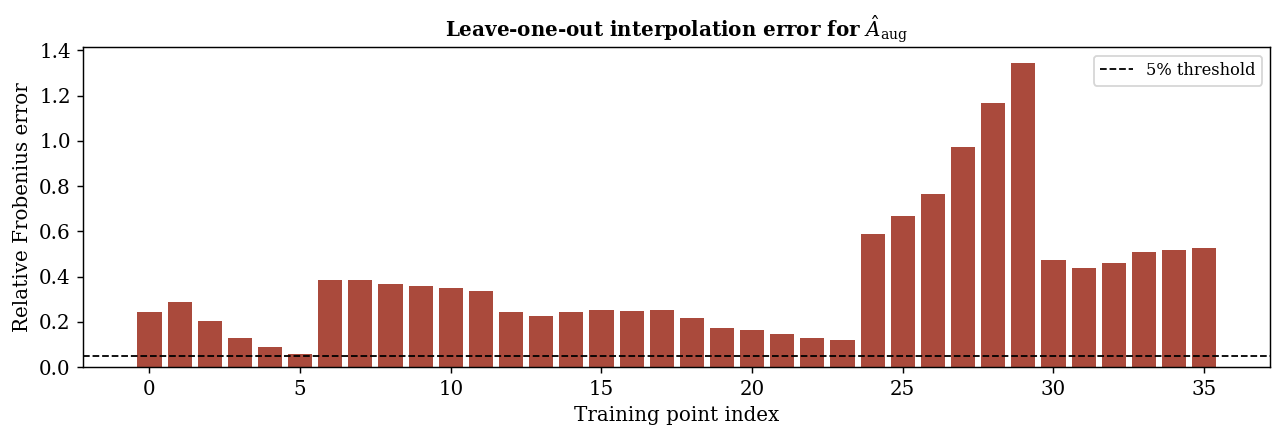

LOO mean : 3.899e-01
LOO max  : 1.345e+00
  ⚠️  LOO mean > 10% — interpolant may be noisy at off-grid points.
Interpolants saved.


In [42]:
# Leave-one-out cross-validation on A_aug
loo_errors = []
for held in range(M_i):
    mask   = np.arange(M_i) != held
    A_flat = A_arr.reshape(M_i, -1)
    A_pred = np.zeros(N_AUG**2)
    for c in range(N_AUG**2):
        rbf = RBFInterpolator(pts_i[mask], A_flat[mask,c],
                              kernel='thin_plate_spline', smoothing=0.0)
        A_pred[c] = rbf(pts_i[[held]])[0]
    err = (np.linalg.norm(A_pred.reshape(N_AUG,N_AUG) - A_arr[held],'fro') /
           np.linalg.norm(A_arr[held],'fro'))
    loo_errors.append(err)
loo_errors = np.array(loo_errors)

fig, ax = plt.subplots(figsize=(10, 3.5))
cols_loo = [C1 if e < 0.05 else C3 for e in loo_errors]
ax.bar(range(M_i), loo_errors, color=cols_loo, alpha=0.85)
ax.axhline(0.05, color='k', ls='--', lw=1, label='5% threshold')
ax.set_xlabel('Training point index'); ax.set_ylabel('Relative Frobenius error')
ax.set_title(r'Leave-one-out interpolation error for $\hat{A}_{\rm aug}$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR/'fig06_loo.pdf', bbox_inches='tight')
plt.show()
print(f'LOO mean : {loo_errors.mean():.3e}')
print(f'LOO max  : {loo_errors.max():.3e}')
if loo_errors.mean() > 0.10:
    print('  ⚠️  LOO mean > 10% — interpolant may be noisy at off-grid points.')

idir = ROM_DIR / 'interpolants'
with open(idir/'A_interp.pkl','wb') as f: pickle.dump({'i':A_interps,'s':A_shape},f)
with open(idir/'B_interp.pkl','wb') as f: pickle.dump({'i':B_interps,'s':B_shape},f)
with open(idir/'meta.json','w') as f:
    json.dump(dict(n_modes=int(N_MODES), n_aug=int(N_AUG), M_train=int(M_i),
                   loo_mean=float(loo_errors.mean()), loo_max=float(loo_errors.max()),
                   lambda_ridge=BEST_L_RIDGE, lambda_mtr=BEST_L_MTR,
                   k_valid=K_GRID, S_valid=S_GRID), f, indent=2)
print('Interpolants saved.')

---
## 10 — Online query and validation

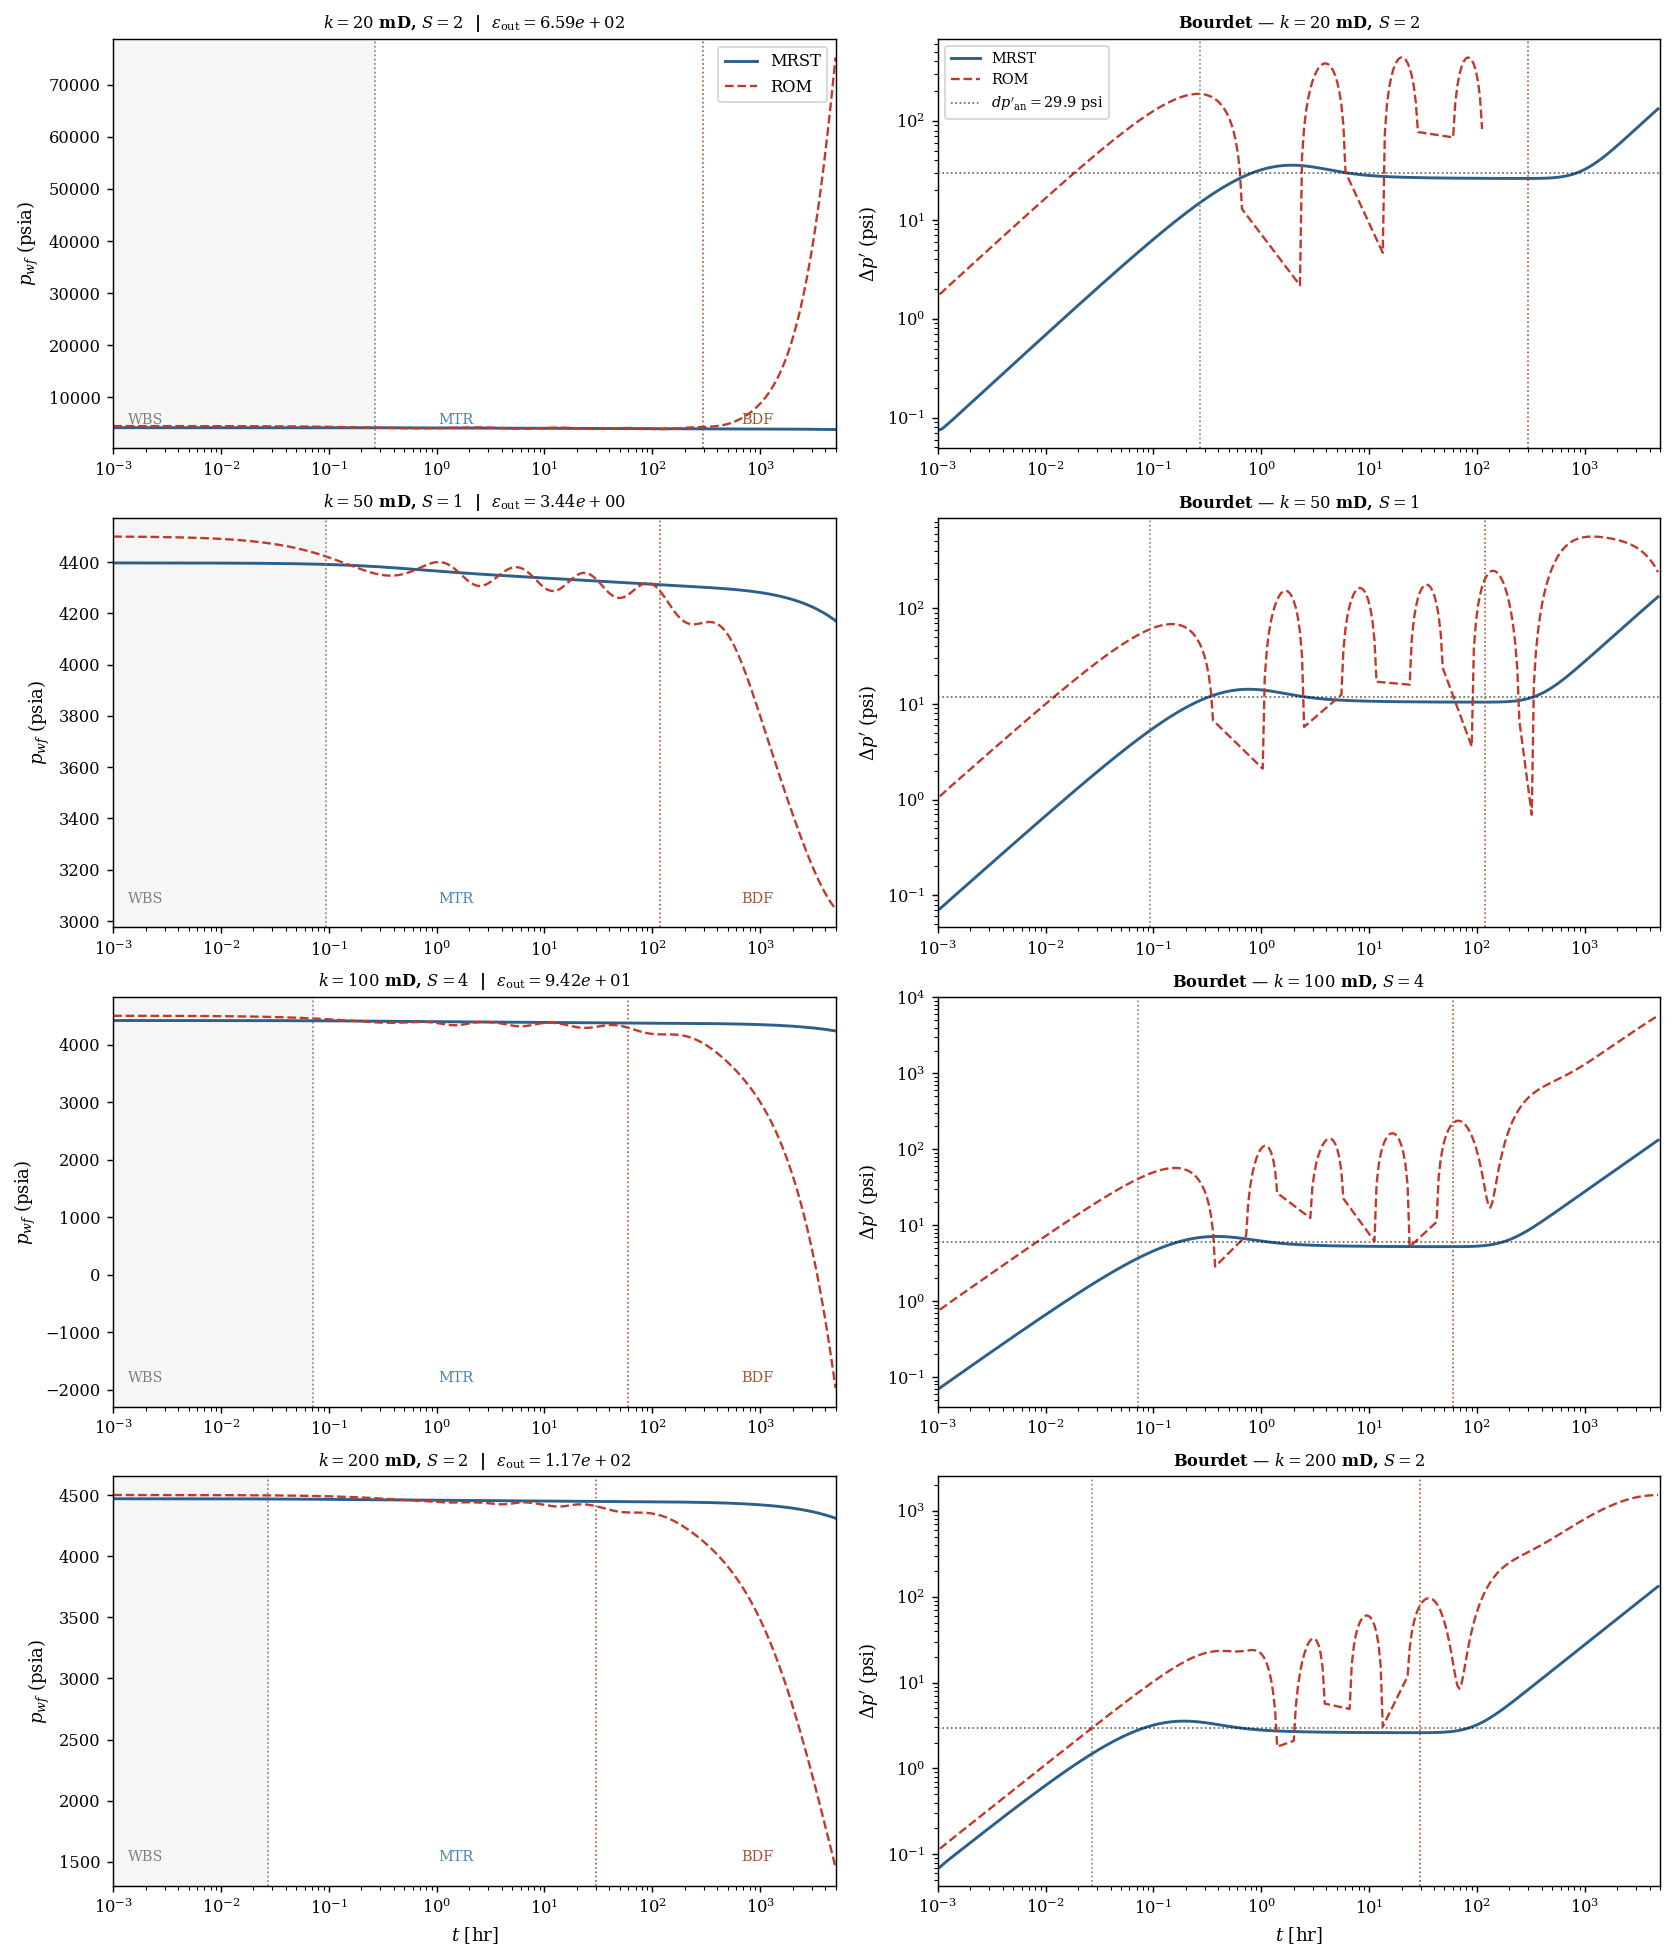

Validation summary:
   case   k  S  state_err  out_err  out_mtr
 k20_s2  20  2   4.66e+02 6.59e+02 2.42e-01
 k50_s1  50  1   4.06e+02 3.44e+00 1.87e-01
k100_s4 100  4   1.84e+02 9.42e+01 3.76e-01
k200_s2 200  2   3.00e+00 1.17e+02 5.44e-01


In [43]:
def query_rom(k_star, s_star, t_hr, q_vec):
    A_hat = eval_op(A_interps, A_shape, k_star, s_star)
    B_hat = eval_op(B_interps, B_shape, k_star, s_star)
    A_hat, _ = stabilise(A_hat)
    Z_rom    = quick_integrate(A_hat, B_hat, t_hr, q_vec)
    bhp_rom  = P_INIT + Z_rom[:, -1]
    Xr       = Z_rom[:, :N_MODES]
    p_field  = P_INIT + Vn @ Xr.T    # [N, K]
    return bhp_rom, p_field, True


test_cases = [(k,s) for k,s in [(20,2),(50,1),(100,4),(200,2)]
              if (k,s) in VALID_PAIRS]
NR = len(test_cases)

# Pre-compute for Cell 11 pressure maps
snap_cache   = {}
t2_records   = []
err_global   = 0.0
dp_global    = 0.0

for k_v, s_v in test_cases:
    cd = TRAINING_DIR / f'k{k_v:03d}_s{s_v:02d}_sched1'
    X_m, bhp_m, t_hr, q_v2, pm = load_case(cd)
    bhp_r, pf_r, _              = query_rom(k_v, s_v, t_hr, q_v2)
    tw = min(t_wbs_fn(k_v,s_v), t_hr[-1])
    tp = min(t_pss_fn(k_v), t_hr[-1])
    mtr = (t_hr >= tw) & (t_hr <= tp)

    # Snapshot at MTR midpoint
    t_snap = np.clip((tw+tp)/2, t_hr[5], t_hr[-5])
    idx    = int(np.argmin(np.abs(t_hr - t_snap)))

    dp_m = (X_m[:,idx] - P_INIT).reshape(NY,NX)
    dp_r = (pf_r[:,idx] - P_INIT).reshape(NY,NX)
    err_global = max(err_global, np.abs(dp_m-dp_r).max())
    dp_global  = max(dp_global,  max(np.abs(dp_m).max(), np.abs(dp_r).max()))

    dXm = X_m - P_INIT; dXr = pf_r - P_INIT
    se = np.linalg.norm(dXm-dXr,'fro')**2 / np.linalg.norm(dXm,'fro')**2
    oe = np.linalg.norm(bhp_m-bhp_r)**2 / np.linalg.norm(bhp_m-P_INIT)**2
    oe_mtr = (np.linalg.norm(bhp_m[mtr]-bhp_r[mtr]) /
              np.linalg.norm(bhp_m[mtr]-P_INIT)) if mtr.sum()>3 else np.nan

    t2_records.append(dict(case=f'k{k_v}_s{s_v}',k=k_v,S=s_v,
                           state_err=se,out_err=oe,out_mtr=oe_mtr))
    snap_cache[(k_v,s_v)] = dict(X_m=X_m,bhp_m=bhp_m,bhp_r=bhp_r,
                                  pf_r=pf_r,t_hr=t_hr,q_v=q_v2,
                                  tw=tw,tp=tp,idx=idx,se=se,oe=oe)

# BHP + Bourdet figure
fig, axes = plt.subplots(NR, 2, figsize=(13, 3.8*NR))

for row,(k_v,s_v) in enumerate(test_cases):
    d    = snap_cache[(k_v,s_v)]
    t_hr = d['t_hr']
    tw, tp = d['tw'], d['tp']

    ax = axes[row,0]
    ax.semilogx(t_hr, d['bhp_m'], lw=1.6, color=C_MRST, label='MRST')
    ax.semilogx(t_hr, d['bhp_r'], lw=1.3, color=C_ROM, ls='--', label='ROM')
    ax.axvspan(t_hr[0], tw, alpha=0.07, color='gray')
    ax.axvline(tw, color='gray',   ls=':', lw=0.9)
    ax.axvline(tp, color='sienna', ls=':', lw=0.9)
    mtr_s = f"{d['oe']:.2e}"
    ax.set_title(f"$k={k_v}$ mD, $S={s_v}$  |  $\\varepsilon_{{\\rm out}}={mtr_s}$",
                 fontsize=9)
    ax.set_ylabel('$p_{wf}$ (psia)', fontsize=10)
    ax.set_xlim([t_hr[0], t_hr[-1]])
    ax.tick_params(labelsize=9)
    if row==0: ax.legend(fontsize=9)
    if row==NR-1: ax.set_xlabel('$t$ [hr]', fontsize=10)
    ax.text(0.02,0.06,'WBS',transform=ax.transAxes,color='gray',    fontsize=8)
    ax.text(0.45,0.06,'MTR',transform=ax.transAxes,color='steelblue',fontsize=8)
    ax.text(0.87,0.06,'BDF',transform=ax.transAxes,color='sienna',  fontsize=8)

    ax2 = axes[row,1]
    dp_m_ts = np.clip(P_INIT - d['bhp_m'], 1e-3, None)
    dp_r_ts = np.clip(P_INIT - d['bhp_r'], 1e-3, None)
    t_bm,_,bd_m = bourdet(t_hr, dp_m_ts)
    t_br,_,bd_r = bourdet(t_hr, dp_r_ts)

    ax2.loglog(t_bm, bd_m, lw=1.6, color=C_MRST, label='MRST')
    ax2.loglog(t_br, bd_r, lw=1.3, color=C_ROM, ls='--', label='ROM')

    dp_an = dp_prime_analytical(k_v, d['q_v'][0])
    ax2.axhline(dp_an, color='k', ls=':', lw=0.9, alpha=0.65,
                label=f"$dp'_{{\\rm an}}={dp_an:.1f}$ psi")
    ax2.axvline(tw, color='gray',   ls=':', lw=0.9)
    ax2.axvline(tp, color='sienna', ls=':', lw=0.9)
    ax2.set_ylabel(r"$\Delta p'$ (psi)", fontsize=10)
    ax2.set_title(f'Bourdet — $k={k_v}$ mD, $S={s_v}$', fontsize=9)
    ax2.set_xlim([t_hr[0], t_hr[-1]])
    ax2.tick_params(labelsize=9)
    if row==0: ax2.legend(fontsize=8)
    if row==NR-1: ax2.set_xlabel('$t$ [hr]', fontsize=10)

plt.tight_layout(h_pad=0.6)
plt.savefig(FIG_DIR/'fig07_validation_bhp_bourdet.pdf', bbox_inches='tight')
plt.show()

t2_df = pd.DataFrame(t2_records)
print('Validation summary:')
print(t2_df[['case','k','S','state_err','out_err','out_mtr']]
      .to_string(index=False, float_format='%.2e'))

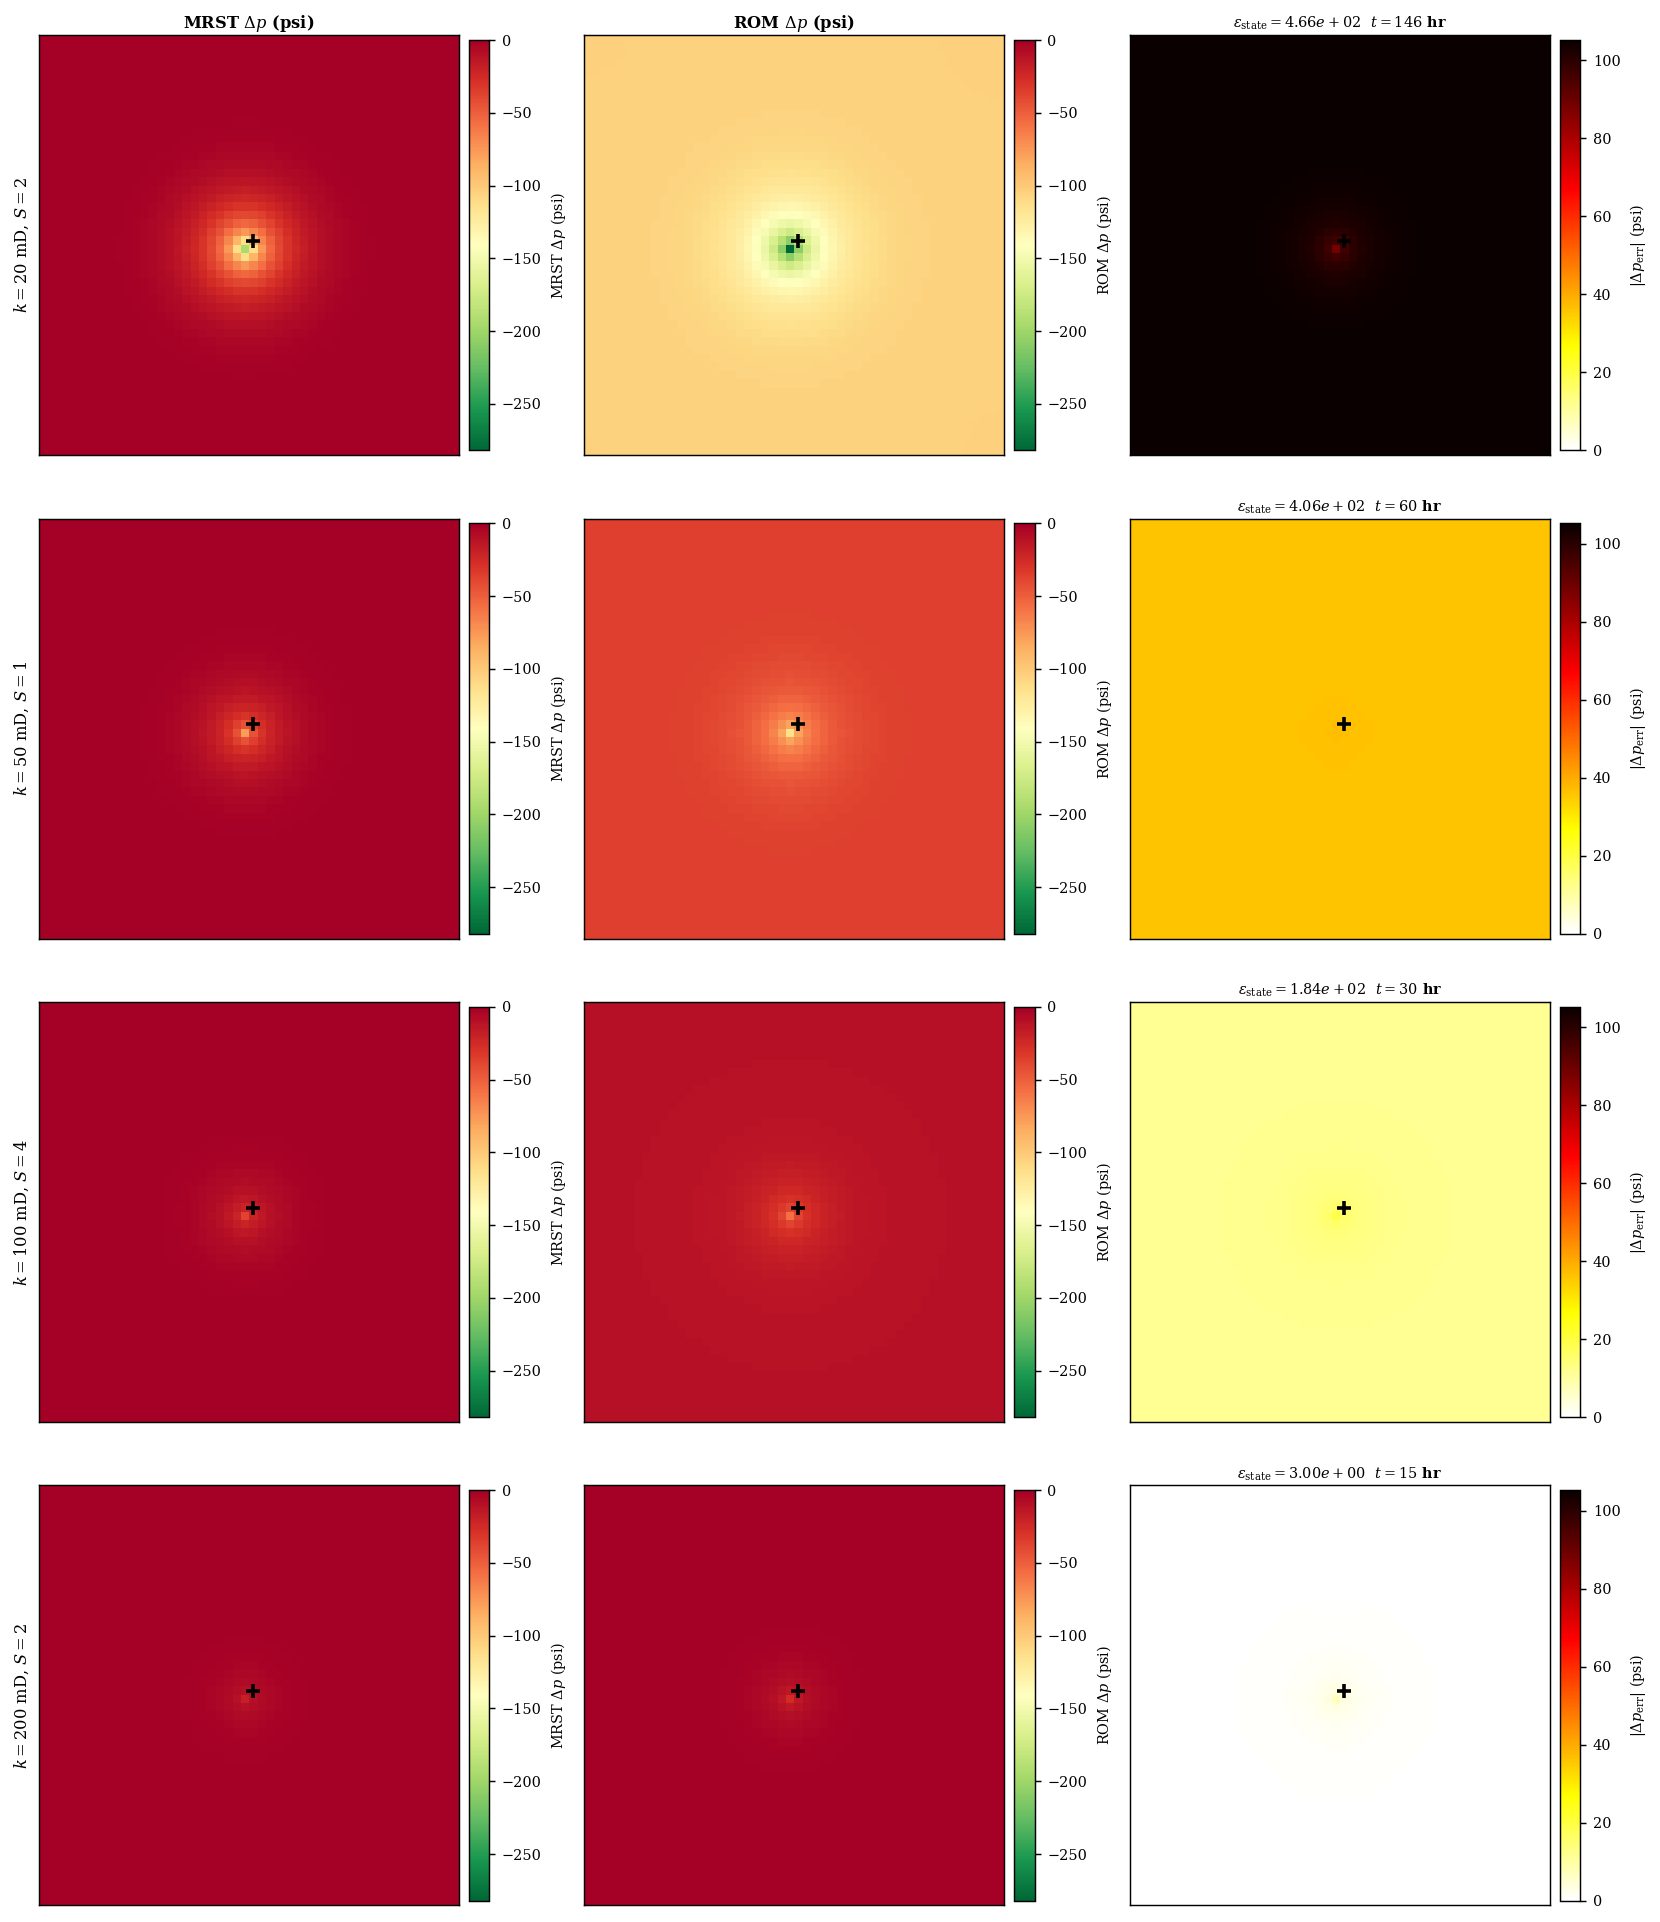

In [44]:
# Pressure field comparison with shared colourscale
fig, axes = plt.subplots(NR, 3, figsize=(13, 3.8*NR))
col_labels = [r'MRST $\Delta p$ (psi)', r'ROM $\Delta p$ (psi)',
              r'$|\Delta p_{\rm err}|$ (psi)']

for row,(k_v,s_v) in enumerate(test_cases):
    d   = snap_cache[(k_v,s_v)]
    idx = d['idx']
    dp_m = (d['X_m'][:,idx] - P_INIT).reshape(NY,NX)
    dp_r = (d['pf_r'][:,idx] - P_INIT).reshape(NY,NX)
    err  = np.abs(dp_m - dp_r)

    panels = [
        (dp_m,'RdYlGn_r',-dp_global, 0,         col_labels[0]),
        (dp_r,'RdYlGn_r',-dp_global, 0,         col_labels[1]),
        (err, 'hot_r',   0,          err_global, col_labels[2]),
    ]
    for col,(dat,cmap,vmin,vmax,cblabel) in enumerate(panels):
        ax = axes[row,col]
        im = ax.imshow(dat, origin='lower', cmap=cmap,
                       vmin=vmin, vmax=vmax, aspect='equal')
        ax.plot(NX//2, NY//2, 'k+', ms=8, mew=2.0, zorder=10)
        ax.set_xticks([]); ax.set_yticks([])
        if row==0: ax.set_title(col_labels[col], fontsize=9, pad=4)
        if col==0: ax.set_ylabel(f'$k={k_v}$ mD, $S={s_v}$', fontsize=9)
        if col==2: ax.set_title(
            f'$\\varepsilon_{{\\rm state}}={d["se"]:.2e}$  '
            f'$t={d["t_hr"][idx]:.0f}$ hr', fontsize=8, pad=4)
        cb = plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02)
        cb.set_label(cblabel, fontsize=8)
        cb.ax.tick_params(labelsize=8)

plt.tight_layout(h_pad=0.4, w_pad=0.2)
plt.savefig(FIG_DIR/'fig08_pressure_fields.pdf', bbox_inches='tight')
plt.show()

---
## 11 — Prediction and parametric studies

Example 1  |  Wall: 7.5 ms
BHP: 4280.9 – 55132.5 psia


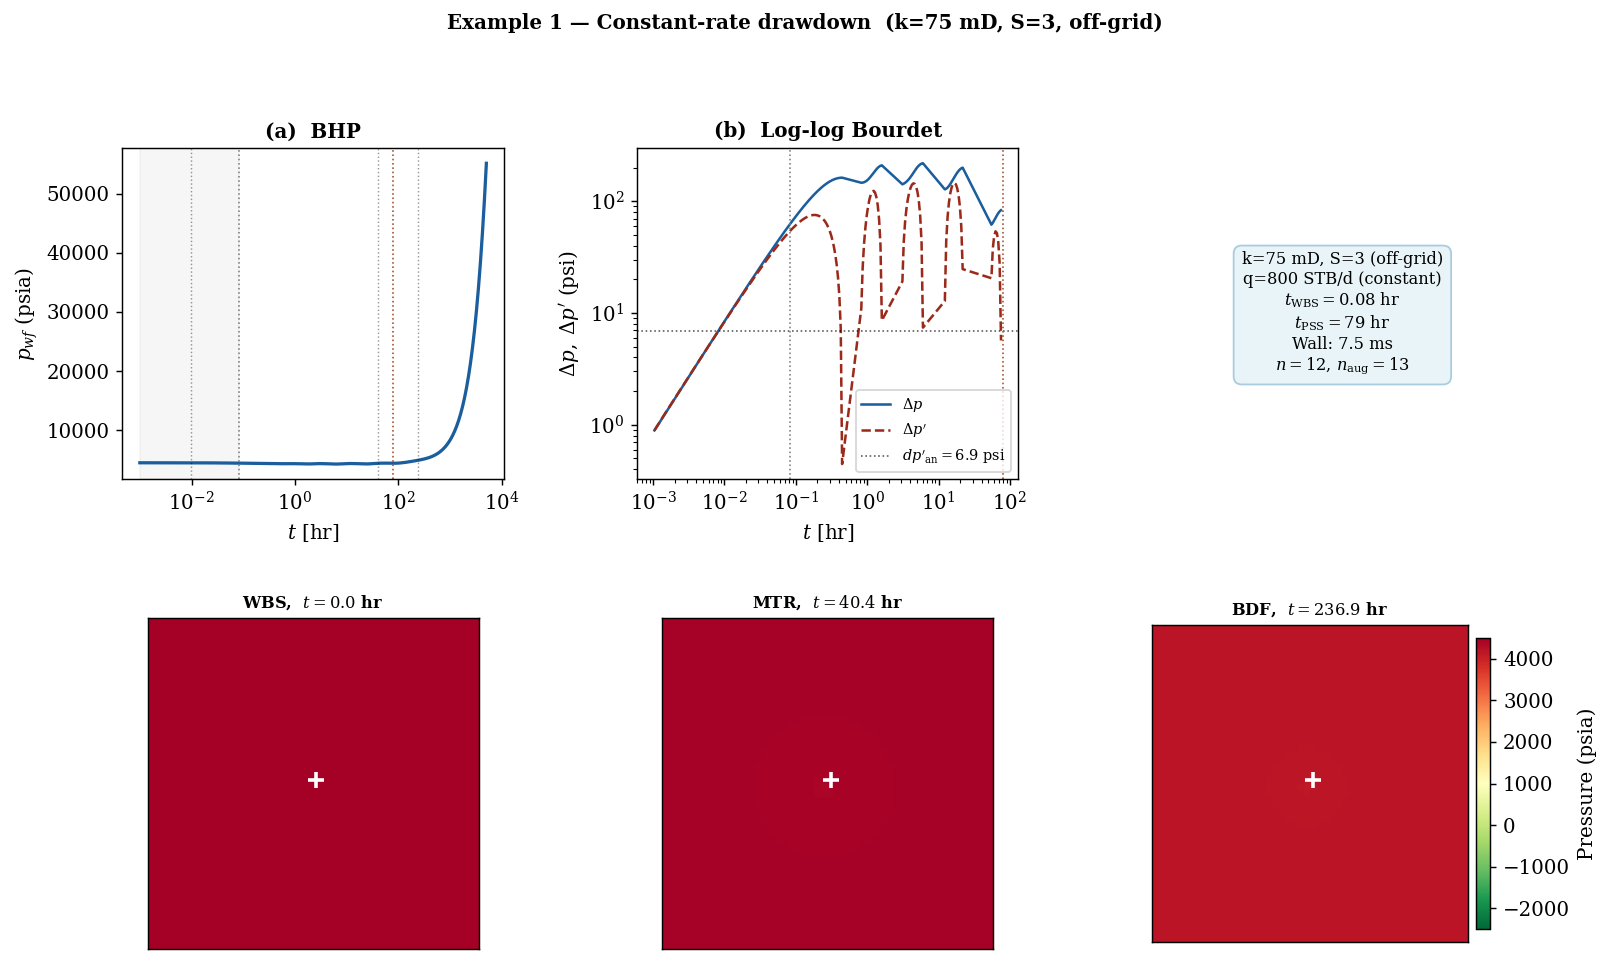

In [45]:
T_PRED = np.logspace(np.log10(T_START), np.log10(T_END), N_STEPS)


def sched_to_q(sched, t_hr):
    q = np.full(len(t_hr), float(sched[0][1]))
    for tc, rv in sched[1:]:
        q[t_hr >= tc] = float(rv)
    return q


def predict(k_star, s_star, rate_sched):
    assert 10 <= k_star <= 300
    assert  0 <= s_star <=  8
    q    = sched_to_q(rate_sched, T_PRED)
    t0   = time.perf_counter()
    bhp, pf, _ = query_rom(k_star, s_star, T_PRED, q)
    return dict(t_hr=T_PRED, bhp_psia=bhp,
                dp_psi=np.clip(P_INIT-bhp, 0, None),
                p_field=pf, q_vec=q,
                wall_ms=(time.perf_counter()-t0)*1000)


# Example 1 — constant rate (off-grid: k=75, S=3)
r1 = predict(75, 3, [(0, 800)])
print(f'Example 1  |  Wall: {r1["wall_ms"]:.1f} ms')
print(f'BHP: {r1["bhp_psia"].min():.1f} – {r1["bhp_psia"].max():.1f} psia')

tw1 = t_wbs_fn(75,3); tp1 = t_pss_fn(75)
dp1 = np.clip(r1['dp_psi'], 1e-3, None)
t_b1,_,bd1 = bourdet(r1['t_hr'], dp1)
dp_an1 = dp_prime_analytical(75, 800)

s_wbs = np.argmin(np.abs(r1['t_hr'] - max(tw1*0.1, 0.01)))
s_mtr = np.argmin(np.abs(r1['t_hr'] - (tw1+tp1)/2))
s_bdf = np.argmin(np.abs(r1['t_hr'] - min(tp1*3, T_END*0.85)))
pmin1 = r1['p_field'].min(); pmax1 = r1['p_field'].max()

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.35)

ax_b = fig.add_subplot(gs[0,0])
ax_b.semilogx(r1['t_hr'], r1['bhp_psia'], lw=1.8, color=C1)
ax_b.axvspan(r1['t_hr'][0], tw1, alpha=0.07, color='gray')
ax_b.axvline(tw1, color='gray',   ls=':', lw=0.9)
ax_b.axvline(tp1, color='sienna', ls=':', lw=0.9)
for si in [s_wbs,s_mtr,s_bdf]:
    ax_b.axvline(r1['t_hr'][si], color='k', ls=':', lw=0.8, alpha=0.4)
ax_b.set_xlabel('$t$ [hr]'); ax_b.set_ylabel('$p_{wf}$ (psia)')
ax_b.set_title('(a)  BHP')

ax_l = fig.add_subplot(gs[0,1])
ax_l.loglog(t_b1, dp1[np.isin(r1['t_hr'], t_b1)],
            lw=1.4, color=C1, label=r'$\Delta p$')
ax_l.loglog(t_b1, bd1, lw=1.4, color=C3, ls='--', label=r"$\Delta p'$")
ax_l.axhline(dp_an1, color='k', ls=':', lw=0.9, alpha=0.65,
             label=f"$dp'_{{\\rm an}}={dp_an1:.1f}$ psi")
ax_l.axvline(tw1, color='gray',   ls=':', lw=0.9)
ax_l.axvline(tp1, color='sienna', ls=':', lw=0.9)
ax_l.set_xlabel('$t$ [hr]'); ax_l.set_ylabel(r"$\Delta p,\;\Delta p'$ (psi)")
ax_l.set_title('(b)  Log-log Bourdet'); ax_l.legend(fontsize=8)

for col,(si,lbl) in enumerate([(s_wbs,'WBS'),(s_mtr,'MTR'),(s_bdf,'BDF')]):
    ax_m = fig.add_subplot(gs[1,col])
    im   = ax_m.imshow(r1['p_field'][:,si].reshape(NY,NX),
                       origin='lower', cmap='RdYlGn_r',
                       vmin=pmin1, vmax=pmax1, aspect='equal')
    ax_m.plot(NX//2, NY//2, 'w+', ms=9, mew=2.0, zorder=5)
    ax_m.set_title(f'{lbl},  $t={r1["t_hr"][si]:.1f}$ hr', fontsize=9)
    ax_m.set_xticks([]); ax_m.set_yticks([])
    if col==2: plt.colorbar(im, ax=ax_m, shrink=0.88, pad=0.02,
                             label='Pressure (psia)')

ax_i = fig.add_subplot(gs[0,2]); ax_i.axis('off')
ax_i.text(0.5,0.5,
    f'k=75 mD, S=3 (off-grid)\nq=800 STB/d (constant)\n'
    f'$t_{{\\rm WBS}}={tw1:.2f}$ hr\n'
    f'$t_{{\\rm PSS}}={tp1:.0f}$ hr\n'
    f'Wall: {r1["wall_ms"]:.1f} ms\n$n={N_MODES}$, $n_{{\\rm aug}}={N_AUG}$',
    ha='center',va='center',fontsize=9,
    bbox=dict(boxstyle='round,pad=0.5',facecolor='#e8f4f8',edgecolor='#aacce0'))

fig.suptitle('Example 1 — Constant-rate drawdown  (k=75 mD, S=3, off-grid)',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig(FIG_DIR/'fig09_example1.pdf', dpi=150, bbox_inches='tight')
plt.show()

Sweep wall time: 35 ms total


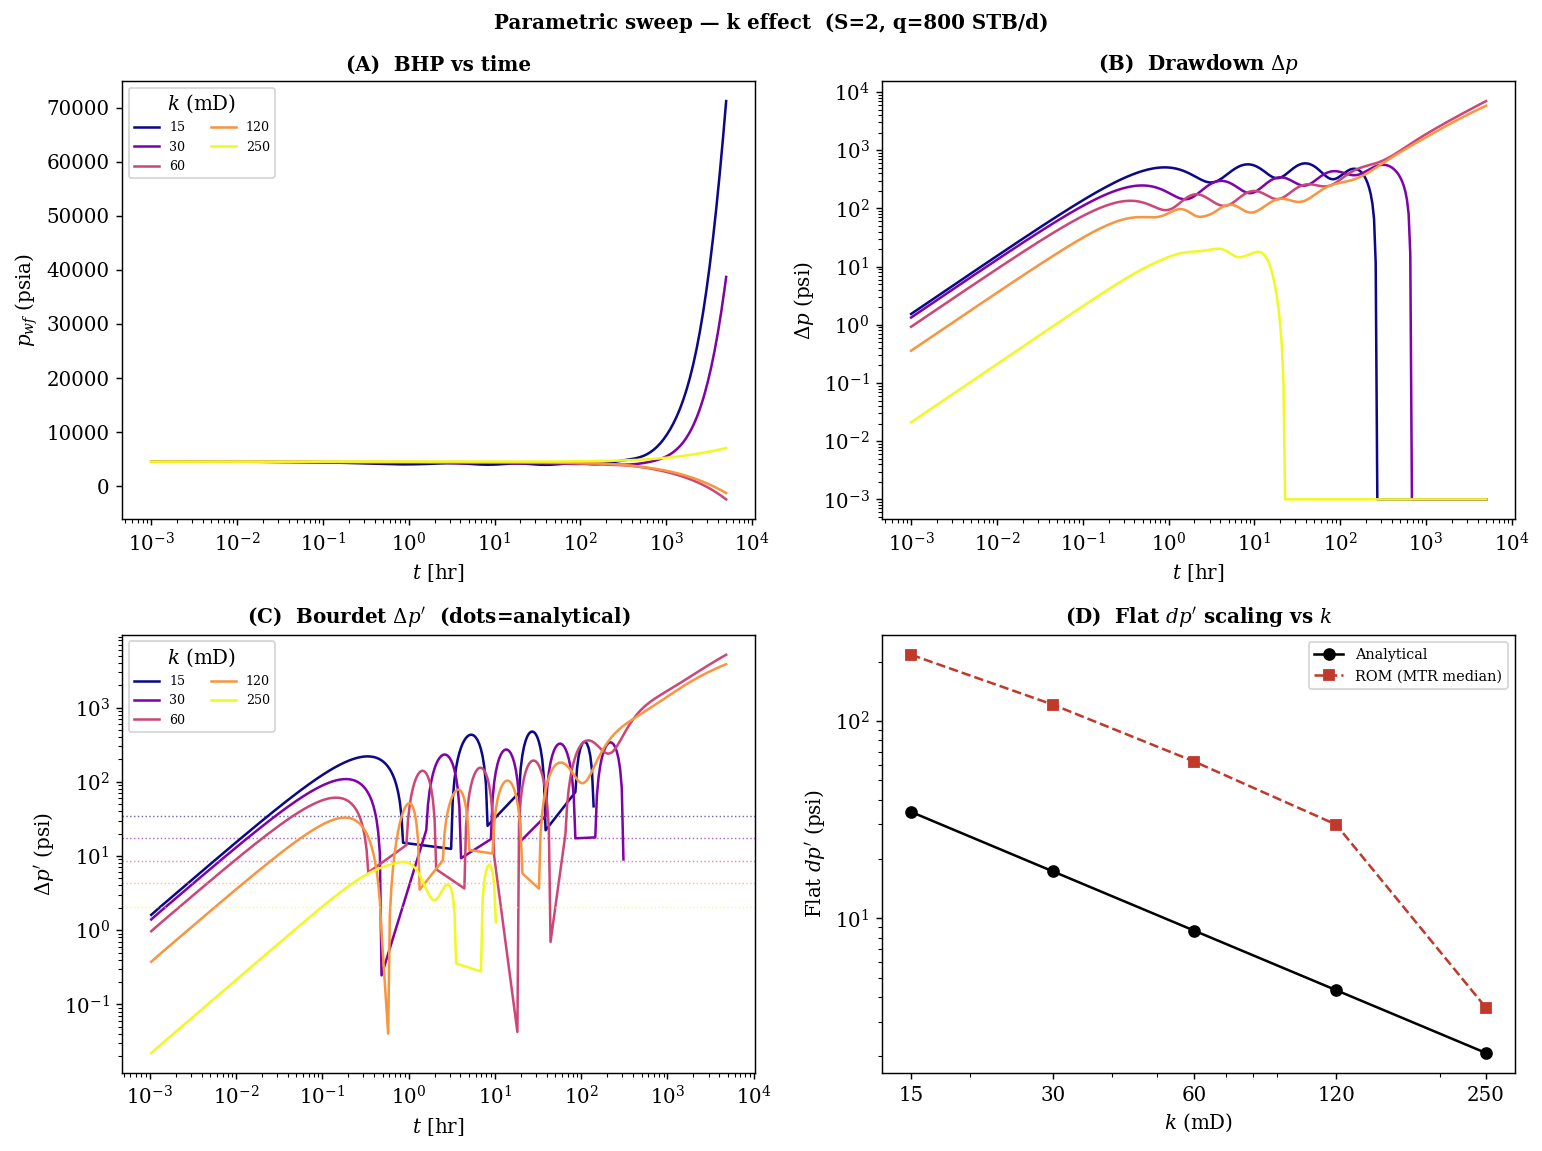

In [46]:
# Parametric k sweep — fixed S=2, q=800 STB/d
k_sweep = [15, 30, 60, 120, 250]
S_fixed = 2
cmap_sw = plt.cm.plasma
cols_sw = [cmap_sw(i/(len(k_sweep)-1)) for i in range(len(k_sweep))]

res_sw  = {k: predict(k, S_fixed, [(0, 800)]) for k in k_sweep}
print(f'Sweep wall time: {sum(r["wall_ms"] for r in res_sw.values()):.0f} ms total')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

dp_an_vals  = [dp_prime_analytical(k,800) for k in k_sweep]
dp_rom_flat = []

for k_v, col in zip(k_sweep, cols_sw):
    r = res_sw[k_v]
    dp_v = np.clip(r['dp_psi'], 1e-3, None)
    t_bv,_,bd_v = bourdet(r['t_hr'], dp_v)
    tw, tp = t_wbs_fn(k_v, S_fixed), t_pss_fn(k_v)
    mtr_b  = (t_bv >= tw) & (t_bv <= tp)

    axes[0,0].semilogx(r['t_hr'], r['bhp_psia'],  color=col, lw=1.4, label=f'{k_v}')
    axes[0,1].loglog(r['t_hr'],   dp_v,           color=col, lw=1.4)
    axes[1,0].loglog(t_bv, bd_v,                  color=col, lw=1.4, label=f'{k_v}')
    axes[1,0].axhline(dp_prime_analytical(k_v,800),
                      color=col, ls=':', lw=0.8, alpha=0.6)
    dp_rom_flat.append(float(np.median(bd_v[mtr_b])) if mtr_b.sum()>3 else np.nan)

axes[1,1].loglog(k_sweep, dp_an_vals, 'k-o', lw=1.4, ms=6, label='Analytical')
axes[1,1].loglog(k_sweep, dp_rom_flat,'s--', lw=1.4, ms=6,
                 color=C_ROM, label='ROM (MTR median)')

ttls = ['(A)  BHP vs time', r'(B)  Drawdown $\Delta p$',
        r"(C)  Bourdet $\Delta p'$  (dots=analytical)",
        r"(D)  Flat $dp'$ scaling vs $k$"]
for ax, ttl in zip(axes.ravel(), ttls):
    ax.set_title(ttl); ax.set_xlabel('$t$ [hr]')
axes[0,0].set_ylabel('$p_{wf}$ (psia)'); axes[0,1].set_ylabel(r'$\Delta p$ (psi)')
axes[1,0].set_ylabel(r"$\Delta p'$ (psi)"); axes[1,1].set_ylabel(r"Flat $dp'$ (psi)")
axes[1,1].set_xlabel('$k$ (mD)')
axes[0,0].legend(title='$k$ (mD)', fontsize=7, ncol=2)
axes[1,0].legend(title='$k$ (mD)', fontsize=7, ncol=2)
axes[1,1].legend(fontsize=8)
axes[1,1].set_xticks(k_sweep); axes[1,1].set_xticklabels(k_sweep)

fig.suptitle(f'Parametric sweep — k effect  (S={S_fixed}, q=800 STB/d)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'fig10_sweep_k.pdf', dpi=150, bbox_inches='tight')
plt.show()

---
## 12 — Performance summary

In [47]:
t0 = time.perf_counter()
for _ in range(20): predict(75, 3, [(0, 800)])
rom_ms = (time.perf_counter()-t0)/20*1000

mrst_s = 9.7   # median from manifest

print('='*62)
print(' PHYSICS-REGULARISED AUGMENTED-STATE ROM — SUMMARY')
print('='*62)
print(f'  Method            : Augmented OpInf + MTR physics penalty')
print(f'  Optimiser         : PyTorch Adam + CosineAnnealingLR')
print(f'  POD modes n       : {N_MODES}')
print(f'  Augmented dim     : {N_AUG}  (BHP as extra state)')
print(f'  Valid (k,S) pts   : {len(VALID_PAIRS)}')
print(f'  Stable operators  : {df_ops["stable"].sum()}/{len(results)}')
print(f'  λ_ridge           : {BEST_L_RIDGE:.0e}')
print(f'  λ_MTR             : {BEST_L_MTR:.2f}')
print(f'  cond(D) median    : {df_ops["cond_D"].median():.2e}')
print(f'  LOO mean error    : {loo_errors.mean():.2e}')
print(f'  State err mean    : {t2_df["state_err"].mean():.2e}')
print(f'  Output err mean   : {t2_df["out_err"].mean():.2e}')
print(f'  ROM wall time     : {rom_ms:.1f} ms/query')
print(f'  MRST wall time    : {mrst_s*1000:.0f} ms/run')
print(f'  Speedup           : ~{mrst_s*1000/rom_ms:.0f}×')
print('='*62)

t2_df.to_csv(ROM_DIR/'results'/'error_summary.csv', index=False)
print('Results saved.')

 PHYSICS-REGULARISED AUGMENTED-STATE ROM — SUMMARY
  Method            : Augmented OpInf + MTR physics penalty
  Optimiser         : PyTorch Adam + CosineAnnealingLR
  POD modes n       : 12
  Augmented dim     : 13  (BHP as extra state)
  Valid (k,S) pts   : 36
  Stable operators  : 36/36
  λ_ridge           : 1e-06
  λ_MTR             : 0.00
  cond(D) median    : 7.04e+04
  LOO mean error    : 3.90e-01
  State err mean    : 2.65e+02
  Output err mean   : 2.18e+02
  ROM wall time     : 8.5 ms/query
  MRST wall time    : 9700 ms/run
  Speedup           : ~1136×
Results saved.
